### Packages

In [1]:
import pandas as pd

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scirpy as ir
import ast
import os
import sys
sys.path.append('analysis scripts')

/Users/yang.an/.local/share/mamba/envs/tcrPrediction/lib/python3.10/site-packages/scirpy/_metadata.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/yang.an/.local/share/mamba/envs/tcrPrediction/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/yang.an/.local/share/mamba/envs/tcrPrediction/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/Users/yang.an/.local/share/mamba/envs/tcrPrediction/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `a

Gephi clustering settings:
- import graph object
- Statistics: Connected Components: Run (standard settings)
- Statistics: Modularity: Run (standard settings)
- Layout: Circle Pack Layout: Hierarchy1 = Component ID, Hierarchy2 = Modularity Class

### Load data

In [2]:
v_info = pd.read_csv('./10X_mouse_vdj/cellranger_mouse_v_ref.csv')
j_info = pd.read_csv('./10X_mouse_vdj/cellranger_mouse_j_ref.csv')

Load processed tcrs

In [3]:
df_tcr = pd.read_excel('./tcr_data/Supplementary table 2 TCR_data_busch_lab_ova_gp33_m45.xlsx', header=4, index_col=0,)

Load processed naive

In [4]:
df_naive_tcr = pd.read_excel('./tcr_data/Supplementary table 3 TCR_data_busch_lab_naive.xlsx', header=4, index_col=0,)

In [5]:
df_naive_tcr.tcr_id.nunique()

82761

Load processed obs

In [6]:
df_obs = pd.read_excel('./tcr_data/Supplementary table 4 TCR_obs_data_busch_lab_ova_gp33_m45.xlsx', header=5, index_col=0,)

### Concat with total dataframe

In [7]:
df_tcr = pd.concat([df_tcr, df_naive_tcr], ignore_index = True)

# the naive table has no annotated_specificity column, so those rows come out NaN
df_tcr['annotated_specificity'] = df_tcr.annotated_specificity.fillna('naive')


In [8]:
df_tcr.annotated_specificity.value_counts()

annotated_specificity
naive    82761
OVA      14678
GP33      8399
M45       4228
Name: count, dtype: int64

In [9]:
df_tcr.sequencing_specificity.value_counts()

sequencing_specificity
naive              82761
below_threshold    10725
OVA                 8647
GP33                5265
M45                 2668
Name: count, dtype: int64

V gene distribution

In [10]:
out = (
    df_tcr.groupby('annotated_specificity')['vb']
      .value_counts(normalize=True)
      .rename('freq')
      .reset_index()
      .set_index('vb')
)
os.makedirs('./manuscript_figures/data_sheets', exist_ok=True)
out.to_excel('./manuscript_figures/data_sheets/vb_freq_any_epitope.xlsx')

# Figure 1

### Plot data distribution

In [11]:
df_obs_backup = df_obs.copy()

In [12]:
#limit to minimum cell count per donor
df_obs = df_obs[df_obs.n_cells_mouse>49].reset_index(drop=True).copy()

#trim again by repertoire size
# remove repertoire overlaps of epitope annotations
mask = ~df_obs['annotated_specificity'].eq(df_obs['isolated_specificity'])
df_obs.loc[mask, 'annotated_specificity'] = 'below_threshold'

#limit to minimum repertoire size per donor to exclude low sequencing donors
df_obs['n_TCRs_mouse'] = df_obs.groupby('mouse')['TCR'].transform('nunique')
df_obs = df_obs[df_obs.n_TCRs_mouse>10].reset_index(drop=True).copy()

# Figure 1 

In [13]:
repertoire_list = [365, 120, 81]
experiment_list = ['OVA','GP33','M45']
color_list = ['#1F77B4','#009E73','#6A3D9A']

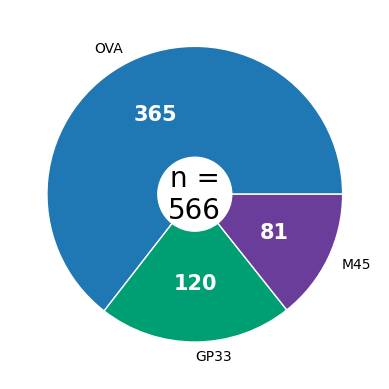

In [14]:
fig, ax = plt.subplots()
size = 0.75
total = sum(repertoire_list)

patches, texts, autotexts = ax.pie(repertoire_list, radius=1, colors=color_list,
       wedgeprops=dict(width=size, edgecolor='w'),
       labels=experiment_list,
       autopct=lambda p: '{:.0f}'.format(p * total / 100),
       textprops={'size': 'medium'})

plt.setp(autotexts, **{'color':'white', 'weight':'bold', 'fontsize':15})
for i in range(len(repertoire_list)):
    autotexts[i].set_color('white')

ax.text(
    0, 0,
    f"n =\n{total}",           # add line break
    ha='center', va='center',
    fontsize=20, fontweight='normal'
)
    
fig.savefig("./manuscript_figures/figure1_data_acquisition.pdf", format="pdf", bbox_inches="tight")

## OVA analysis

In [15]:
df_obs_n4 = df_obs.loc[(df_obs.sequencing_specificity=='OVA')&(df_obs.isolated_specificity=='OVA')].reset_index(drop=True).copy()

In [16]:
df_obs.loc[(df_obs.sequencing_specificity=='OVA')].tcr_id.nunique()

8922

In [17]:
def annotate_exp(exp):
    exp = exp.lower()  # normalize
    if "cd107a" in exp:
        return "CD107a"
    elif "cd44hi" in exp:
        return "CD44hi"
    elif "mult" in exp:
        return "multimer_pos"
    elif "pa_n4" in exp:
        return "multimer_pos"   
    else:
        return None  # ignores mult_neg and mult_pos

# Apply function
df_obs_n4["exp_type"] = df_obs_n4["experiment"].apply(annotate_exp)

In [18]:
repertoires = (df_obs_n4.groupby('exp_type')
              .agg(mouse_counts=('mouse', 'nunique'))
              .reset_index()
    )
repertoires

,exp_type,mouse_counts
0,CD107a,237
1,CD44hi,30
2,multimer_pos,98


In [19]:
repertoire_list = [98, 30, 237]
experiment_list = ['Multimer','CD44hi','CD107a']
color_list_exp = ['#b25454', '#368785', '#CFA85F']

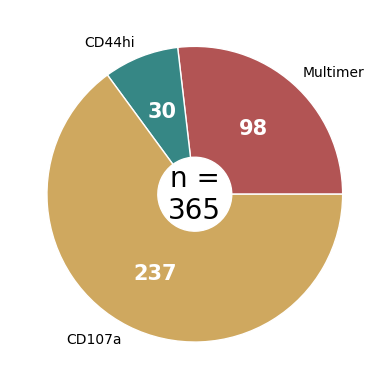

In [20]:

fig, ax = plt.subplots()
size = 0.75
total = sum(repertoire_list)

patches, texts, autotexts = ax.pie(repertoire_list, radius=1, colors=color_list_exp,
       wedgeprops=dict(width=size, edgecolor='w'),
       labels=experiment_list,
       autopct=lambda p: '{:.0f}'.format(p * total / 100),
       textprops={'size': 'medium'})

plt.setp(autotexts, **{'color':'white', 'weight':'bold', 'fontsize':15})
for i in range(3):
    autotexts[i].set_color('white')

ax.text(
    0, 0,
    f"n =\n{total}",           # add line break
    ha='center', va='center',
    fontsize=20, fontweight='normal'
)
    
fig.savefig("./manuscript_figures/figure1_data_acquisition_ova_epxeriment.pdf", format="pdf", bbox_inches="tight")

### TCR identification by experiment

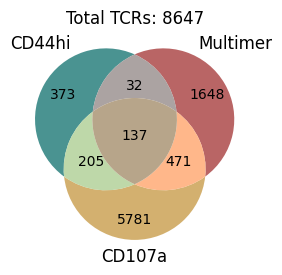

In [21]:
from matplotlib_venn import venn3
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm

df_obs_n4 = df_obs_backup.loc[(df_obs_backup.sequencing_specificity=='OVA')&(df_obs_backup.annotated_specificity!='below_threshold')].reset_index(drop=True).copy()

# Sets
set_cd44 = set(df_obs_n4.TCR[df_obs_n4.exp_type=='CD44hi'].unique())
set_multimer = set(df_obs_n4.TCR[df_obs_n4.exp_type=='multimer_pos'].unique())
set_cd107 = set(df_obs_n4.TCR[df_obs_n4.exp_type=='CD107a'].unique())

layout = DefaultLayoutAlgorithm(fixed_subset_sizes=(1, 1, 1, 1, 1, 1, 1))

# Correct order: match subsets -> labels -> colors
subsets=[set_cd44, set_multimer, set_cd107]
set_labels=('CD44hi', 'Multimer', 'CD107a')
color_list_venn = ['#368785', '#b25454', '#CFA85F']  # CD44hi, Multimer, CD107a

# Plot
fig, ax = plt.subplots(figsize=(3,3))

venn3(
    subsets=subsets,
    set_labels=set_labels,
    set_colors=color_list_venn,
    alpha=0.9,
    ax=ax,
    layout_algorithm=layout
)

ax.set_title("Total TCRs: " + str(df_obs_n4.TCR.nunique()))

fig.savefig("./manuscript_figures/figure1_TCR_ident_ova_epxeriment.pdf", format="pdf", bbox_inches="tight")


TCR counts by sequencing annotation

/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/1137917079.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')


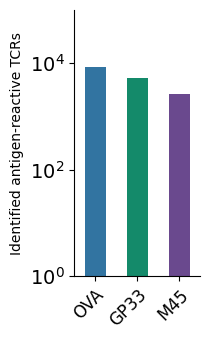

In [22]:
epitope_list = ['OVA','GP33','M45']
color_list = ['#1F77B4','#009E73','#6A3D9A']

df_temp = pd.DataFrame(df_tcr.groupby('sequencing_specificity').agg(
    tcr_counts_seq = ('tcr_id','nunique'))
)

df_temp2 = pd.DataFrame(df_tcr.groupby('predicted_specificity').agg(
    tcr_counts_pred = ('tcr_id','nunique'))
)
df_plot = df_temp.merge(df_temp2, left_index=True, right_index=True, how='inner')
df_plot = df_plot.drop(index=('below_threshold'))


colors = color_list

fig, ax = plt.subplots(figsize = (2.2,3.5))
sns.barplot(df_plot, x = df_plot.index, y='tcr_counts_seq', ax=ax, palette=colors, legend=False, hue = df_plot.index,
            order = epitope_list, hue_order = epitope_list, width = 0.5)
    
ax.set_xlabel('')
ax.set_ylim(1,100000)
ax.set_yscale('log')
ax.set_ylabel('Identified antigen-reactive TCRs')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')
ax.tick_params(axis='y', labelsize = 14)


fig.tight_layout()

fig.savefig("./manuscript_figures/figure1_tcr_counts_seq_only.pdf", format="pdf", bbox_inches="tight")

/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/1077619854.py:26: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/1077619854.py:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


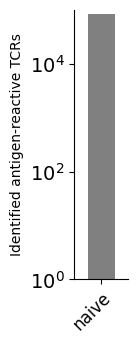

In [23]:
epitope_list = ['naive']
color_list = ['gray']

df_temp = pd.DataFrame(df_tcr.groupby('sequencing_specificity').agg(
    tcr_counts_seq = ('tcr_id','nunique'))
)

# only tcr_counts_seq is plotted here; merging on predicted_specificity dropped
# 'naive', which is NaN in that column, leaving an empty panel
df_plot = df_temp.drop(index='below_threshold')


colors = color_list

fig, ax = plt.subplots(figsize = (0.7,3.5))
sns.barplot(df_plot, x = df_plot.index, y='tcr_counts_seq', ax=ax, palette=colors, legend=False, hue = df_plot.index,
            order = epitope_list, hue_order = epitope_list, width = 0.5)
    
ax.set_xlabel('')
ax.set_ylim(1,100000)
ax.set_yscale('log')
ax.set_ylabel('Identified antigen-reactive TCRs')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')
ax.tick_params(axis='y', labelsize = 14)


fig.tight_layout()

fig.savefig("./manuscript_figures/figure1_naive_only.pdf", format="pdf", bbox_inches="tight")

/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/2982191405.py:18: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')


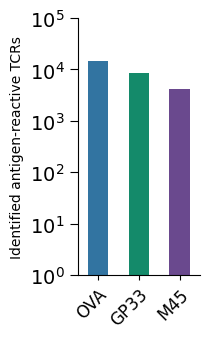

In [24]:
epitope_list = ['OVA','GP33','M45']
color_list = ['#1F77B4','#009E73','#6A3D9A']

df_plot = pd.DataFrame(df_tcr.groupby('annotated_specificity').agg(
    tcr_counts_anot = ('tcr_id','nunique'))
)
colors = color_list

fig, ax = plt.subplots(figsize = (2.2,3.5))
sns.barplot(df_plot, x = df_plot.index, y='tcr_counts_anot', ax=ax, palette=colors, legend=False, hue = df_plot.index,
            order = epitope_list, hue_order = epitope_list, width = 0.5)
    
ax.set_xlabel('')
ax.set_ylabel('Identified antigen-reactive TCRs')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')
ax.tick_params(axis='y', labelsize = 14)

from matplotlib.ticker import LogLocator, LogFormatterMathtext, LogFormatter

ax.set_yscale('log')
ax.set_ylim(1, 100000)


ax.yaxis.set_major_locator(LogLocator(base=10, numticks=12))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=range(2, 10)))

ax.yaxis.set_major_formatter(LogFormatter(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))

# explicitly force minor tick visibility
ax.tick_params(axis='y', which='minor', length=3)
ax.tick_params(axis='y', which='major', length=6)



fig.tight_layout()

fig.savefig("./manuscript_figures/figure1_tcr_counts_predicted.pdf", format="pdf", bbox_inches="tight")

Below threshold TCRs

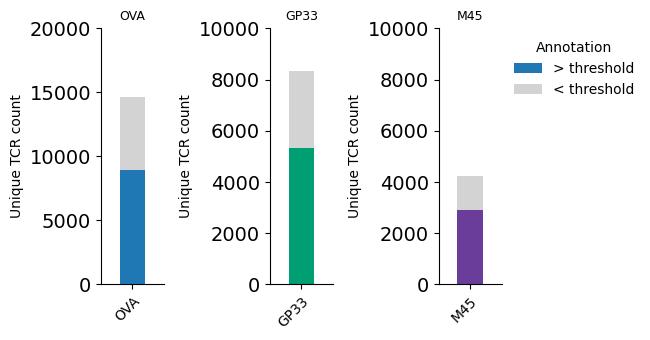

In [25]:
#split obs df by epitope to match old code
df_list = []
epitope_list = ['OVA','GP33','M45']
color_list = ['#1F77B4','#009E73','#6A3D9A']
colors = color_list

from matplotlib.patches import Patch


ylims = [20000, 10000, 10000]

bar_width = 0.4
x_limits = (-0.5, 0.5)

fig, axes = plt.subplots(
    ncols=len(epitope_list),
    figsize=(2.2 * len(epitope_list), 3.5),
    squeeze=False,
)

axes = axes.ravel()

for i, ep in enumerate(epitope_list):
    ax = axes[i]

    df_temp = df_obs.loc[
        df_obs["isolated_specificity"].eq(ep)
    ].copy()

    # Count unique TCRs using annotated specificity only
    annotated_pred = df_temp.loc[
        df_temp["annotated_specificity"].eq(ep),
        "TCR",
    ].nunique()

    annotated_seq = df_temp.loc[
        df_temp["sequencing_specificity"].eq(ep),
        "TCR",
    ].nunique()

    # Annotated-negative segment stacked on top
    ax.bar(
        x=0,
        height=annotated_pred,
        width=bar_width,
        color="lightgray",
        edgecolor="none",
        label="Annotated negative",
    )
    # Epitope-positive segment at the bottom
    ax.bar(
        x=0,
        height=annotated_seq,
        width=bar_width,
        color=colors[i],
        edgecolor="none",
        label="Annotated epitope",
    )

    ax.set_xticks([0])
    ax.set_xticklabels([ep])

    # Fixed x limits prevent autoscaling from masking bar-width changes
    ax.set_xlim(x_limits)

    ax.set_ylabel("Unique TCR count")
    ax.set_title(ep, fontsize=9)

    if ylims is not None:
        ax.set_ylim(0, ylims[i])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="x",
        labelrotation=45,
    )
    ax.tick_params(
        axis="y",
        labelsize=14,
    )

    for label in ax.get_xticklabels():
        label.set_ha("right")
        label.set_rotation_mode("anchor")

legend_handles = [
    Patch(
        facecolor=colors[0],
        edgecolor="none",
        label="> threshold",
    ),
    Patch(
        facecolor="lightgray",
        edgecolor="none",
        label="< threshold",
    ),
]

axes[-1].legend(
    handles=legend_handles,
    title="Annotation",
    loc="upper left",
    bbox_to_anchor=(1, 1),
    frameon=False,
)

fig.tight_layout()
fig.savefig("./manuscript_figures/figure1_tcr_counts_classification_one_bar.pdf", format="pdf", bbox_inches="tight")

-

-

-

-

# Figure 2

### Recruited repertoire size

In [26]:
#split obs df by epitope to match old code
df_list = []
epitope_list = ['OVA','GP33','M45']
color_list = ['#1F77B4','#009E73','#6A3D9A']
for ep in epitope_list:
    temp = df_obs[df_obs.annotated_specificity==ep].reset_index(drop=True).copy()
    df_list.append(temp)

/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/3157900377.py:27: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')


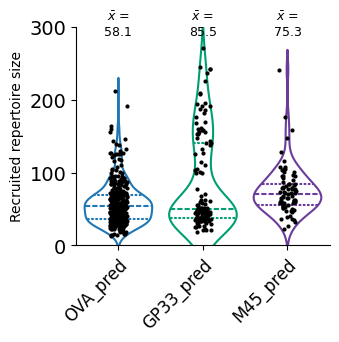

In [27]:
size_list = []
for i, df_plot in enumerate(df_list):
    # reduce to only sequencing annotated TCRs
    df_plot = df_plot[df_plot.annotated_specificity==epitope_list[i]].copy()
    # format df for plotting
    df_size = pd.DataFrame(df_plot.groupby('mouse').agg(
    tcr_counts = ('TCR','nunique')
    ))
    df_size['group'] = epitope_list[i] + '_pred'
    size_list.append(df_size)
    ######## save data for plotting in Prism
    #df_size.to_excel('./prism_plotting_data/' + epitope_list[i] + '_seq_repertoire_size.xlsx')
    

long_df = pd.concat(size_list, ignore_index=True)

fig, ax = plt.subplots(figsize = (3.5,3.5))
colors = color_list
sns.stripplot(long_df, x = 'group', y='tcr_counts', ax=ax, color='black', size = 3)
sns.violinplot(long_df, x = 'group', y='tcr_counts', ax=ax, fill = False, color = 'gray', inner="quart", hue = 'group', palette = colors)
    
ax.set_xlabel('')
ax.set_ylabel('Recruited repertoire size')
ax.set_ylim(0, 300)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')

# Get x-axis group labels in the correct plotting order
xtick_labels = [tick.get_text() for tick in ax.get_xticklabels()]
group_means = long_df.groupby('group')['tcr_counts'].mean()

# Vertical offset from top
y_offset = ax.get_ylim()[1] * 0.05

# Annotate each group
ax.tick_params(axis='y', labelsize = 14)

for i, label in enumerate(xtick_labels):
    mean_val = group_means[label]
    ax.text(i, ax.get_ylim()[1] - y_offset, f"$\\bar{{x}}$ =\n{mean_val:.1f}",
            ha='center', va='bottom', fontsize=9)

fig.tight_layout()

fig.savefig("./manuscript_figures/figure2_repertoire_size_pred.pdf", format="pdf", bbox_inches="tight")

## Pgen correlation to sharedness

/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/4283814120.py:124: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14, rotation_mode='anchor')
/Users/yang.an/.local/share/mamba/envs/tcrPrediction/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/4283814120.py:202: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14, rotation_mode='anchor')
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/4283814120.py:124: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14, rotation_mode='

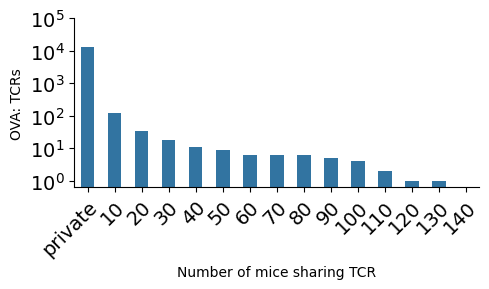

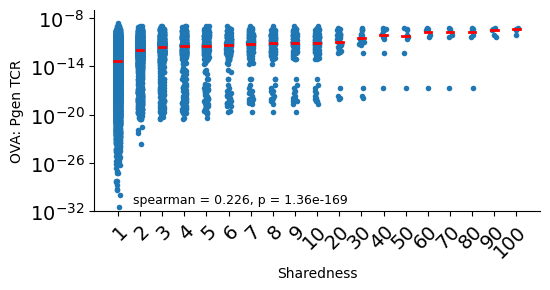

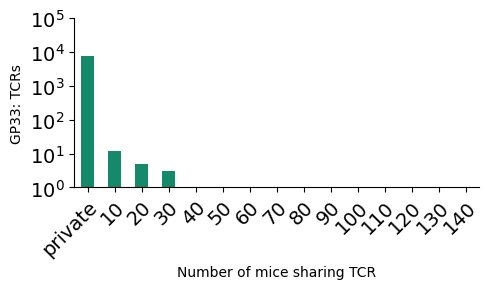

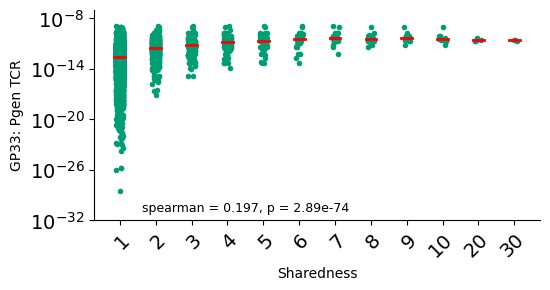

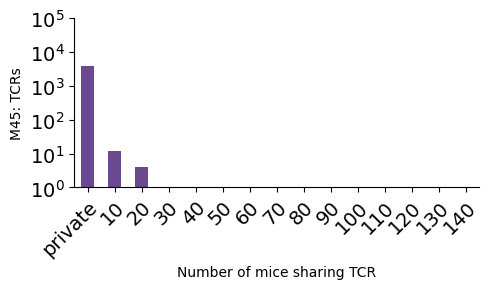

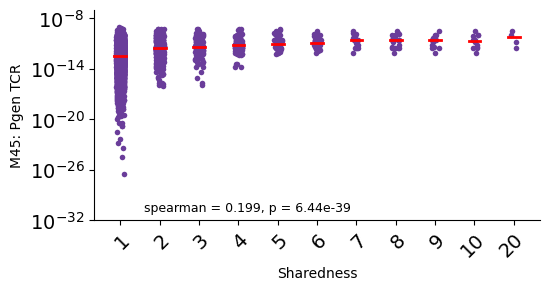

In [28]:
cluster_dfs = []
for ep in epitope_list:
    temp = df_tcr[df_tcr.annotated_specificity == ep ].reset_index(drop=True).copy()
    cluster_dfs.append(temp)
	
	
from scipy.stats import linregress, spearmanr

def regression_and_spearman(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
) -> pd.Series:

    data = df[[x_col, y_col]].copy()

    data[x_col] = pd.to_numeric(
        data[x_col],
        errors="coerce",
    )
    data[y_col] = pd.to_numeric(
        data[y_col],
        errors="coerce",
    )

    data = (
        data
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if len(data) < 3:
        raise ValueError(
            "At least three complete observations are required."
        )

    x = data[x_col].to_numpy(dtype=float)
    y = data[y_col].to_numpy(dtype=float)

    if np.unique(x).size < 2:
        raise ValueError(
            f"{x_col!r} must contain at least two unique values."
        )

    # Linear regression: y = intercept + slope * x
    regression = linregress(x, y)

    # Spearman rank correlation
    spearman = spearmanr(
        x,
        y,
        alternative="two-sided",
        nan_policy="omit",
    )

    results = pd.Series(
        {
            "x_column": x_col,
            "y_column": y_col,
            "n": len(data),

            "slope": regression.slope,
            "intercept": regression.intercept,
            "pearson_r": regression.rvalue,
            "r_squared": regression.rvalue**2,
            "regression_p_value": regression.pvalue,
            "slope_standard_error": regression.stderr,

            "spearman_rho": spearman.statistic,
            "spearman_p_value": spearman.pvalue,
        },
        name="result",
    )

    return results
	
	
color_list = ['#1F77B4', '#009E73', '#6A3D9A']
correlation_results = []

for i, ep in enumerate(epitope_list):
    # ------------------------------
    # 1) Compute sharedness per TCR
    # ------------------------------
    df_plot = cluster_dfs[i].groupby('tcr_id').agg(
        cdr3a_aa = ('cdr3a_aa','first'),
        cdr3b_aa = ('cdr3b_aa','first'),
        #mouse = ('mouse', set),
        shared_mouse = ('shared_mouse','max'),
        clonotype = ('tcr_id','first'),
        shared_clonotype = ('tcr_id','nunique')
    ).dropna()

    # Define thresholds for "at least X mice"
    thresholds = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140]

    # Compute counts per threshold
    counts = []
    for t in thresholds:
        if t == 1:
            counts.append((t, (df_plot['shared_mouse'] == 1).sum()))
        else:
            counts.append((t, (df_plot['shared_mouse'] >= t).sum()))

    bin_counts = pd.DataFrame(counts, columns=['mouse_bin_value', 'count'])
    bin_counts['mouse_bin'] = bin_counts['mouse_bin_value'].apply(lambda x: 'private' if x==1 else str(x))

    # Plot sharedness
    fig, ax = plt.subplots(figsize=(5,3))
    sns.barplot(
        data=bin_counts, 
        x="mouse_bin", 
        y="count", 
        color = color_list[i], 
        width=0.5,
        ax=ax
    )
    ax.set_yscale('log')
    ax.set_yticks(np.geomspace(1, 100000 ,6).round())
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.xlabel("Number of mice sharing TCR")
    plt.ylabel(ep + ": TCRs")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14, rotation_mode='anchor')
    ax.tick_params(axis='y', labelsize = 14)
    plt.tight_layout()
    fig.savefig(f"./manuscript_figures/{ep}_overall_sharedness.pdf", format="pdf", bbox_inches="tight")

    # ------------------------------
    # 2) Compute Pgen expansion
    # ------------------------------
    cluster_dfs[i]['pgen_tcr'] = cluster_dfs[i]['pgen_cdr3_a_aa'] * cluster_dfs[i]['pgen_cdr3_b_aa']

    df_pgen = cluster_dfs[i].groupby('tcr_id').agg(
        shared_mouse = ('shared_mouse','max'),
        pgen_tcr = ('pgen_tcr','first'),
        pgen_cdr3a = ('pgen_cdr3_a_aa','first'),
        pgen_cdr3b = ('pgen_cdr3_b_aa','first'),
        clone_size_mouse = ('norm_TCR_expansion','max')
    ).dropna()
    df_pgen['pgen_log10'] = np.log10(df_pgen['pgen_tcr'])
    
    # correlation
    results = regression_and_spearman(
        df=df_pgen,
        x_col="shared_mouse",
        y_col="pgen_log10",
    )
    correlation_results.append(results)
    spearman_rho = f"{results['spearman_rho']:.3f}"
    p_val = f"{results['spearman_p_value']:.3g}"
    
    # Define thresholds for cumulative bins
    thresholds_exp = [1, 2,3,4,5,6,7,8,9,10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

    # Vectorized expansion
    expanded_list = []
    for t in thresholds_exp:
        if t == 1:
            mask = df_pgen['shared_mouse'] == 1
        else:
            mask = df_pgen['shared_mouse'] >= t
        tmp = df_pgen.loc[mask, ['pgen_tcr']].copy()
        tmp['shared_cat'] = str(t) if t > 1 else '1'
        expanded_list.append(tmp)

    df_expanded = pd.concat(expanded_list, ignore_index=True)

    # Ensure ordering for plotting
    cat_order = [str(t) for t in thresholds_exp]

    # ------------------------------
    # 3) Plot Pgen per sharedness bin
    # ------------------------------
    fig, ax = plt.subplots(figsize=(5.6,3))
    sns.stripplot(
        data=df_expanded,
        x='shared_cat', y='pgen_tcr',
        order=cat_order,
        color = color_list[i],  size=4, linewidth=0,
        ax=ax
    )

    # Plot median per bin
    median_width = 0.3
    for j, cat in enumerate(cat_order):
        median_val = df_expanded[df_expanded['shared_cat']==cat]['pgen_tcr'].median()
        if pd.notna(median_val):
            ax.plot([j-median_width/2, j+median_width/2], [median_val, median_val], lw=2, color='r', zorder=10)

    ax.text(
        0.5,
        10**-31,
        f" spearman = {spearman_rho}, p = {p_val}",
        fontsize = 9,)

    ax.set_yscale('log')
    ax.set_xlabel('Sharedness')
    ax.set_ylabel(ep + ': Pgen TCR')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14, rotation_mode='anchor')
    ax.tick_params(axis='y', labelsize = 14)
    ax.set_ylim(1e-32, 1e-7)
    plt.tight_layout()
    fig.savefig(f"./manuscript_figures/figure2_{ep}_overall_pgen.pdf", format="pdf", bbox_inches="tight")

-

-

-

-

# Figure 3 

Baseline

In [29]:
df_naive = pd.read_excel('./tcr_data/Supplementary table 5 TCR_obs_data_busch_lab_naive.xlsx', header=4, index_col=0,)

In [30]:
FW_LIST = ['trav', 'traj', 'trbv', 'trbj']
FW_INDICES = {'va': 0, 'ja': 1, 'vb': 2, 'jb': 3}

# ---------- 1) Compute framework counts ----------
def get_framework(df: pd.DataFrame) -> list[pd.DataFrame]:
    temp = df.groupby('TCR').agg(
        trav=('IR_VJ_1_v_call', 'first'),
        traj=('IR_VJ_1_j_call', 'first'),
        trbv=('IR_VDJ_1_v_call', 'first'),
        trbj=('IR_VDJ_1_j_call', 'first')
    ).dropna()

    return [temp[col].value_counts(normalize=True).to_frame() for col in FW_LIST]

# ---------- 2) Fold-change calculation ----------
def calculate_fold_change(sample_s: pd.Series, naive_s: pd.Series, fw: str, ep: str) -> pd.DataFrame:
    merged = pd.merge(sample_s, naive_s, left_index=True, right_index=True, how='inner', suffixes=('', '_naive'))
    merged.columns = [f'{fw}_{ep}', f'{fw}_naive']
    merged['fc'] = merged[f'{fw}_{ep}'] / merged[f'{fw}_naive']
    return merged

def get_all_fold_changes(fw_lists_all: list[list[pd.DataFrame]], naive_fw_list: list[pd.DataFrame], epitope_list: list[str]):
    results = {}
    for ep, sample_frames in zip(epitope_list, fw_lists_all):
        for fw, idx in FW_INDICES.items():
            sample_s = sample_frames[idx].iloc[:,0]
            naive_s = naive_fw_list[idx].iloc[:,0]
            sample_s.name = f'{fw}_{ep}'
            naive_s.name  = f'{fw}_naive'
            results[(ep, fw)] = calculate_fold_change(sample_s, naive_s, fw, ep)
    return results

def merge_fc(all_fc_dfs, epitope_list, fw_code):
    return pd.concat([all_fc_dfs[(ep, fw_code)]['fc'].rename(ep) for ep in epitope_list], axis=1)



df relates hier to all processed epitopes, reduced to single TCR copies

In [31]:
epitope_list = ['OVA', 'GP33', 'M45']

df_list = []
for ep in epitope_list:
    temp = df_obs[df_obs.isolated_specificity==ep].reset_index(drop=True).copy()
    df_list.append(temp)

# calc naive framework
naive_fw_list = get_framework(df_naive)

# MAKE SURE DF_LIST IS THE RESPECTIVE OBS DF PER EPITOPE
fw_lists_all = [get_framework(df[df['annotated_specificity'] == epitope_list[i]]) for i, df in enumerate(df_list)]

all_fc_dfs = get_all_fold_changes(fw_lists_all, naive_fw_list, epitope_list)

# Merge for va/vb/ja/jb
va_merged = merge_fc(all_fc_dfs, epitope_list, 'va')
vb_merged = merge_fc(all_fc_dfs, epitope_list, 'vb')
ja_merged = merge_fc(all_fc_dfs, epitope_list, 'ja')
jb_merged = merge_fc(all_fc_dfs, epitope_list, 'jb')



In [32]:
naive_fw_list[2].to_excel("./manuscript_figures/data_sheets/naive_vbeta_dis.xlsx")
naive_fw_list[0].to_excel("./manuscript_figures/data_sheets/naive_valpha_dis.xlsx")

In [33]:
fw_lists_all[0][0].to_excel("./manuscript_figures/data_sheets/OVA_valpha_dis.xlsx")
fw_lists_all[0][2].to_excel("./manuscript_figures/data_sheets/OVA_vbeta_dis.xlsx")

fw_lists_all[1][0].to_excel("./manuscript_figures/data_sheets/GP33_valpha_dis.xlsx")
fw_lists_all[1][2].to_excel("./manuscript_figures/data_sheets/GP33_vbeta_dis.xlsx")

fw_lists_all[2][0].to_excel("./manuscript_figures/data_sheets/M45_valpha_dis.xlsx")
fw_lists_all[2][2].to_excel("./manuscript_figures/data_sheets/M45_vbeta_dis.xlsx")

Seperate by epitope and naive

In [34]:
color_list = ['darkgray','#1F77B4', '#009E73', '#6A3D9A']
epitope_list = ['naive','OVA','GP33','M45']
#sort x axis from log2 data
#x_axis_list = df_log2.index.tolist()

df_list_plot = []
for ep in epitope_list:
    temp = df_tcr[df_tcr.annotated_specificity==ep].reset_index(drop=True).copy()
    temp.jb = temp.jb.str.replace('TRBJ', 'jβ', regex=False)
    temp = pd.DataFrame(temp.jb.value_counts(normalize = True))
    temp['freq'] = temp['proportion']*100
    df_list_plot.append(temp)

jb_order = df_list_plot[0].index.tolist()

df_list_plot = []
for ep in epitope_list:
    temp = df_tcr[df_tcr.annotated_specificity==ep].reset_index(drop=True).copy()
    temp.vb = temp.vb.str.replace('TRBV', 'Vβ', regex=False)
    temp = pd.DataFrame(temp.vb.value_counts(normalize = True))
    temp['freq'] = temp['proportion']*100
    df_list_plot.append(temp)

vb_order = df_list_plot[0].index.tolist()

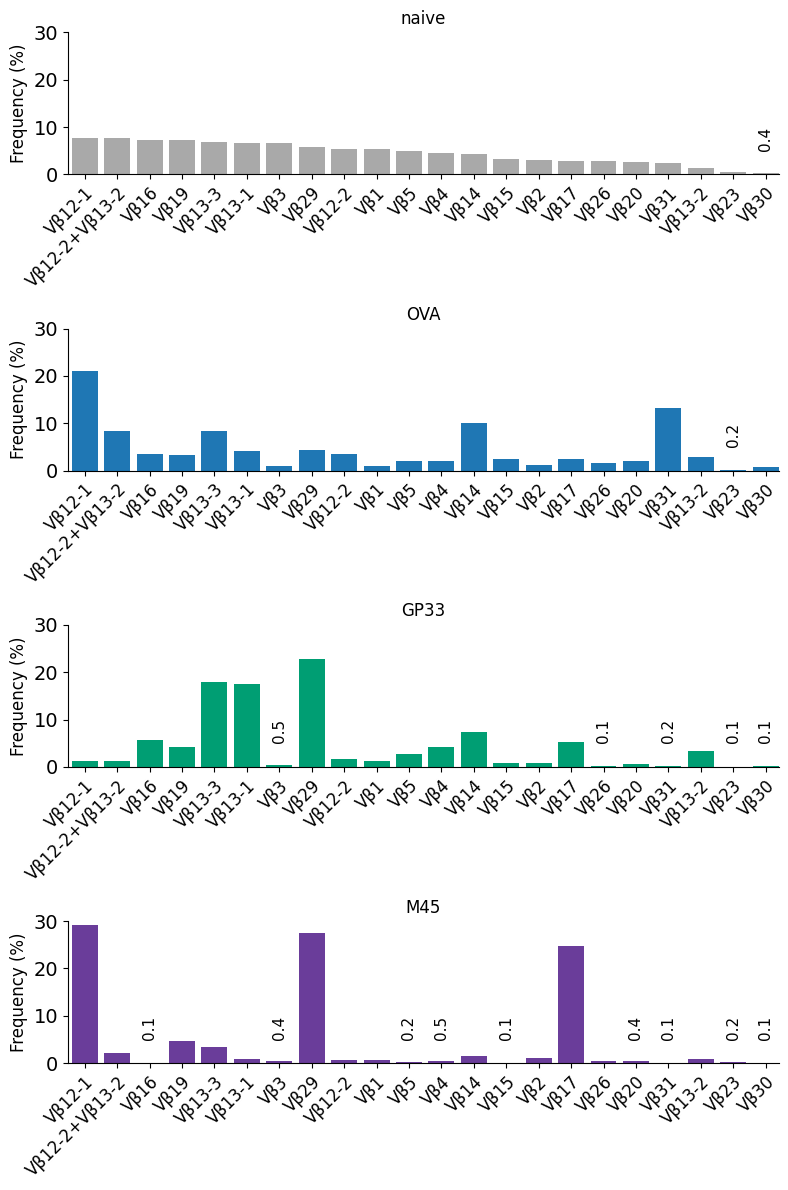

In [35]:
color_list = ['darkgray','#1F77B4', '#009E73', '#6A3D9A']
epitope_list = ['naive','OVA','GP33','M45']

# ============================================================
# Settings
# ============================================================

ymin = 0
ymax = 30

bar_width = 0.8
small_bar_threshold = 0.5
left_bar_offset = 0.12

# Fixed y-coordinate for labels on small bars
small_bar_text_y = 5


# ============================================================
# Calculate TRBV frequencies for each epitope
# ============================================================

df_list_plot = []

for ep in epitope_list:
    temp = (
        df_tcr.loc[
            df_tcr["annotated_specificity"].eq(ep),
            ["vb"],
        ]
        .copy()
    )

    temp["vb"] = (
        temp["vb"]
        .str.replace(
            "TRBV",
            "Vβ",
            regex=False,
        )
    )

    freq_df = (
        temp["vb"]
        .dropna()
        .value_counts(normalize=True)
        .mul(100)
        .rename("freq")
        .to_frame()
    )

    df_list_plot.append(freq_df)


# Use the TRBV order from the first epitope
vb_order = df_list_plot[0].index.tolist()


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    nrows=len(epitope_list),
    ncols=1,
    figsize=(8, 12),
    squeeze=False,
)

axes = axes.ravel()

for i, (ep, df_freq) in enumerate(
    zip(epitope_list, df_list_plot)
):
    ax_i = axes[i]

    # Add missing TRBV genes as zero-frequency categories
    plot_df = (
        df_freq
        .reindex(
            vb_order,
            fill_value=0,
        )
        .copy()
    )

    x = np.arange(len(vb_order))
    heights = plot_df["freq"].to_numpy(dtype=float)

    bars = ax_i.bar(
        x=x,
        height=heights,
        width=bar_width,
        color=color_list[i],
        edgecolor="none",
    )

    # --------------------------------------------------------
    # Labels for very small bars
    # --------------------------------------------------------

    for bar, height in zip(bars, heights):
        if 0 < height < small_bar_threshold:
            ax_i.text(
                x=bar.get_x() + bar.get_width() / 2,
                y=small_bar_text_y,
                s=f"{height:.1f}",
                ha="center",
                va="bottom",
                rotation=90,
                fontsize=11,
                clip_on=True,
            )

    # --------------------------------------------------------
    # Axis labels and formatting
    # --------------------------------------------------------

    ax_i.set_title(
        ep,
        fontsize=12,
    )

    ax_i.set_xlabel("")
    ax_i.set_ylabel(
        "Frequency (%)",
        fontsize=12,
    )

    ax_i.set_xticks(x)

    ax_i.set_xticklabels(
        vb_order,
        rotation=45,
        ha="right",
        fontsize=12,
        rotation_mode="anchor",
    )

    ax_i.tick_params(
        axis="y",
        labelsize=14,
    )

    ax_i.spines["top"].set_visible(False)
    ax_i.spines["right"].set_visible(False)

    # Remove the outer horizontal margins.
    # Limits match the outer edges of the first and last bars.
    if len(x) > 0:
        ax_i.set_xlim(
            x[0] - bar_width / 2 - left_bar_offset,
            x[-1] + bar_width / 2,
        )

    # Fixed y-axis range
    ax_i.set_ylim(
        ymin,
        ymax,
    )

    # Prevent subsequent artists from changing the y limits
    ax_i.autoscale(
        enable=False,
        axis="y",
    )


fig.tight_layout()
fig.savefig('./manuscript_figures/figure3_vbeta_dist_seperated_by_naive.pdf')

## Calculate: Vb enrichment in naive repertoire correlated with pgen

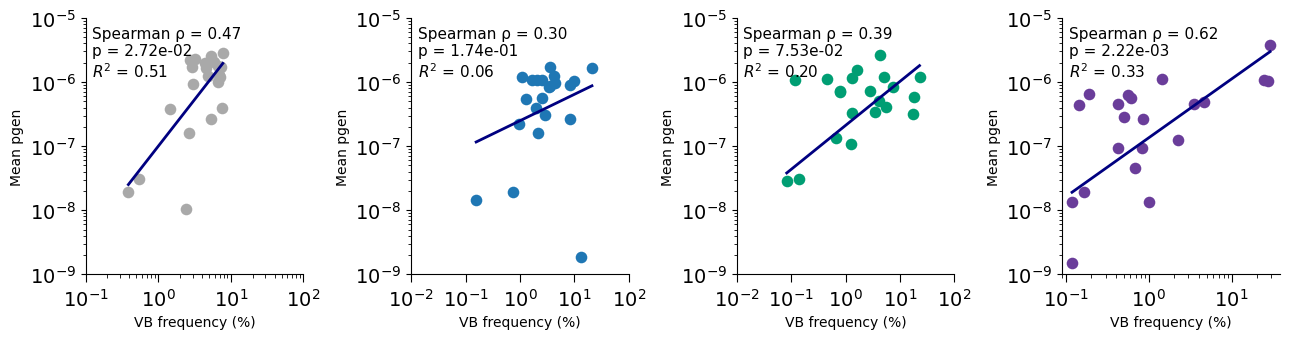

In [36]:
from scipy.stats import spearmanr
from scipy.stats import linregress

epitope_list = ['naive','OVA', 'GP33', 'M45']
color_list = ['darkgray','#1F77B4', '#009E73', '#6A3D9A']

fig, ax = plt.subplots(ncols = 4, figsize=(13, 3.5))

for i, ep in enumerate(epitope_list):
    df_vb = (
        df_tcr[df_tcr.annotated_specificity==ep].reset_index(drop=True)
        .groupby("vb")
        .agg(
            frequency=("vb", "size"),
            mean_pgen=("pgen_cdr3_b_aa", "mean"),
        )
    )
    
    df_vb["frequency"] = (
        df_vb["frequency"] /
        df_vb["frequency"].sum()
    )*100
    
    df_vb = df_vb.reset_index()
       
    
    sns.scatterplot(
        data=df_vb,
        x="frequency",
        y="mean_pgen",
        s=70,
        ax=ax[i],
        color = color_list[i],
        linewidth = 0,
    )
    
    ax[i].set_xscale("log")
    ax[i].set_yscale("log")
    ax[i].set_ylim(1e-9, 1e-5)

    # Plot correleation line and spearman
    r, p = spearmanr(
        np.log10(df_vb["frequency"]),
        np.log10(df_vb["mean_pgen"])
    )
    
    x = np.log10(df_vb["frequency"])
    y = np.log10(df_vb["mean_pgen"])
    
    fit = linregress(x, y)
    
    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = fit.slope * x_fit + fit.intercept
    r2 = fit.rvalue**2
    
    ax[i].plot(
        10**x_fit,
        10**y_fit,
        color="navy",
        lw=2,
    )
    
    ax[i].text(
        0.03,
        0.97,
        f"Spearman ρ = {r:.2f}\n"
        f"p = {p:.2e}\n"
        f"$R^2$ = {r2:.2f}\n",
        #f"slope = {fit.slope:.2f}",
        transform=ax[i].transAxes,
        ha="left",
        va="top",
        fontsize=11,
    )
    
    ax[i].set_xlabel("VB frequency (%)")
    ax[i].set_ylabel("Mean pgen")
    ax[i].tick_params(axis='x', which='major', labelsize=14)
    ax[i].tick_params(axis='y', which='major', labelsize=14)
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)

    from matplotlib.ticker import LogLocator, LogFormatterMathtext, LogFormatter   
    ax[i].xaxis.set_major_locator(LogLocator(base=10, numticks=12))
    ax[i].xaxis.set_minor_locator(LogLocator(base=10, subs=range(2, 10)))
    
    ax[i].xaxis.set_major_formatter(LogFormatter(base=10))
    ax[i].xaxis.set_major_formatter(LogFormatterMathtext(base=10))
    
    # explicitly force minor tick visibility
    ax[i].tick_params(axis='x', which='minor', length=3)
    ax[i].tick_params(axis='x', which='major', length=6)



ax[0].set_xlim(0.1, 100)
ax[1].set_xlim(0.01, 100)
ax[2].set_xlim(0.01, 100)

fig.tight_layout()
fig.savefig('./manuscript_figures/figure3_pgen_vs_vb_freq_epitopes.pdf')

Vb log2 fc

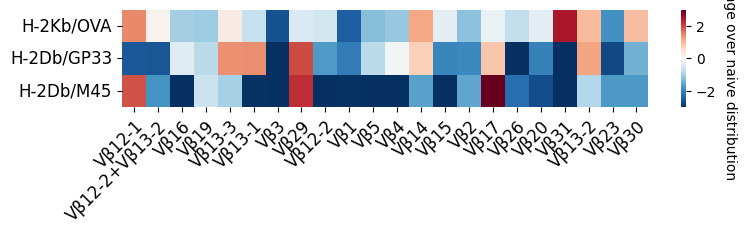

In [37]:
fig, ax = plt.subplots(figsize=(8, 2.5))

#cmaps
# 'berlin', 'managua', 'vanimo'
df_log2 = vb_merged.apply(lambda col: np.log2(col) if np.issubdtype(col.dtype, np.floating) else col)

df_log2.index = df_log2.index.str.replace('TRBV', 'Vβ', regex=False)
df_log2 = df_log2.reindex(vb_order)
#df_log2 = df_log2.sort_values(by=['OVA','M38','GP33','M45'],ascending=False)
sns.heatmap(
    data=df_log2.fillna(0).T,  # transpose for vertical epitope labels
    ax=ax,
    vmin=-3,
    vmax=3,
    cmap='RdBu_r',
    #yticklabels=['H-2Kb/OVA', 'H-2Kb/M38', 'H-2Db/GP33','H-2Db/M45']
    yticklabels=['H-2Kb/OVA','H-2Db/GP33','H-2Db/M45']
)

cbar = ax.collections[0].colorbar
cbar.set_label('fold change over naive distribution', rotation=270, labelpad=15)
#cbar.set_ticks([0, 1, 2, 3])
#cbar.set_ticklabels(['0','1','2','3'])

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)
ax.set_xlabel('')

fig.tight_layout()
fig.savefig("./manuscript_figures/figure3_vbeta_fold_change.pdf", format="pdf", bbox_inches="tight")

Percentage of most dominant TRBVs

In [38]:
df = df_tcr

In [39]:
epitope_list = ['OVA', 'GP33', 'M45']
for ep in epitope_list:
    df_temp = df[df.annotated_specificity==ep]
    df_temp = df_temp.drop_duplicates(subset=["tcr_id"], keep="first").copy()
    df_temp = df_temp.reset_index(drop=True).copy()
    top_3 = df_temp.vb.value_counts()[:3].index.tolist()
    counts_top3 = df_temp[df_temp.vb.isin(top_3)].tcr_id.nunique()
    counts_all = df_temp.tcr_id.nunique()
    freq = counts_top3/counts_all*100
    print(counts_all)
    print(counts_top3)
    print(freq)

14678
6481
44.15451696416405
8399
4906
58.41171568043815
4228
3444
81.45695364238411


## Gini index of Vb and Va change

Gini Index

In [40]:
df_obs_naive = df_naive

In [41]:
import gini_trav_vs_trbv as gini_v

epitope_list = [
    "OVA",
    "GP33",
    "M45",
]

(gini_delta_df,baseline_gini_per_donor,baseline_gini_summary,) = gini_v.calculate_epitope_baseline_gini_delta(
    df_baseline=df_obs_naive,
    df_epitope=df_obs,
    epitopes=epitope_list,

    donor_col="mouse",
    epitope_col="annotated_specificity",

    trav_col="IR_VJ_1_v_call",
    trbv_col="IR_VDJ_1_v_call",

    # Groups with fewer observations receive NaN
    min_observations=3,
)

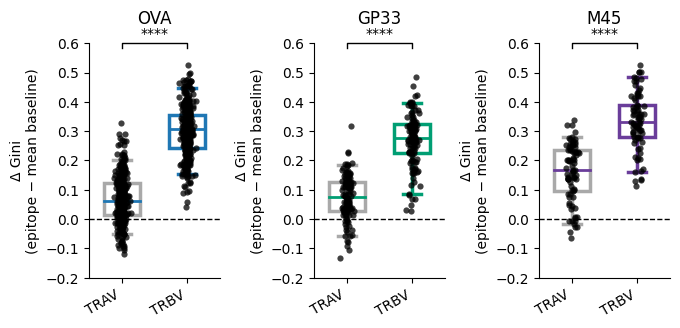

In [42]:
epitope_colors = {
    "OVA": "#1F77B4",
    "GP33": "#009E73",
    "M45": "#6A3D9A",
}

results = gini_v.plot_delta_gini_trav_vs_trbv(
    data=gini_delta_df,
    epitopes=epitope_list,

    donor_col="mouse",
    epitope_col="annotated_specificity",
    chain_col="chain",
    value_col="delta_gini",

    epitope_colors=epitope_colors,

    chain_order=(
        "TRAV",
        "TRBV",
    ),

    # Box outlines
    trav_color="darkgray",
    trbv_color=None,          # epitope color

    # Panel dimensions
    ncols=4,
    subplot_size=(2.3, 3.4),

    # Axis settings
    xlim=(0.5, 2.5),
    ylim=(-0.2, 0.6),
    reference_line=0,

    # Boxplot settings
    whis=(5, 95),
    boxplot_width=0.55,
    box_linewidth=2.5,

    # None means epitope color for both median lines
    median_color=None,
    median_linewidth=2.0,

    # Points
    point_color="black",
    point_size=20,
    point_alpha=0.75,
    point_jitter=0.045,

    # Optional donor-pair connections
    connect_pairs=False,
    pair_line_color="0.75",
    pair_linewidth=0.8,
    pair_line_alpha=0.6,

    # Statistics
    p_adjust="holm-sidak",
    stat_label="stars",
    stat_bracket_y=0.98,
    stat_text_y=1.01,

    save_pdf=True,
    pdf_path=(
        "./manuscript_figures/figure3_delta_gini_TRAV_vs_TRBV.pdf"
    ),
)

fig = results["fig"]

axes = np.asarray(results["axes"])

# Desired size of each subplot in inches
subplot_width = 2.5
subplot_height = 3.2

# Determine subplot grid dimensions
if axes.ndim == 1:
    nrows = 1
    ncols = axes.size
else:
    nrows, ncols = axes.shape

fig.set_size_inches(
    subplot_width * ncols,
    subplot_height * nrows,
    forward=True,
)

axes = np.asarray(results["axes"]).ravel()

for ax in axes:
    if not ax.get_visible():
        continue

    ax.tick_params(
        axis="y",
        which="both",
        labelsize=14,
        labelleft=True,
    )

fig.savefig("./manuscript_figures/figure3_delta_gini_TRAV_vs_TRBV.pdf")

Annotate germline recombinations

In [43]:
#old helper
df_tcr['gene_recombination'] = df_tcr['va'] + '_' + df_tcr['ja'] + '__' + df_tcr['vb'] + '_' + df_tcr['jb']
df_naive_tcr['gene_recombination'] = df_naive_tcr['va'] + '_' + df_naive_tcr['ja'] + '__' + df_naive_tcr['vb'] + '_' + df_naive_tcr['jb']

## annotate pgen
df_tcr['pgen_cdr3_ab'] = df_tcr['pgen_cdr3_a_aa'] * df_tcr['pgen_cdr3_b_aa']

#genes
df_naive_tcr['tra_trb_vj'] = df_naive_tcr['gene_recombination'].copy()
df_tcr['tra_trb_vj'] = df_tcr['gene_recombination'].copy()
#genes
df_naive_tcr['trb_vj'] = df_naive_tcr['vb'] + '_' + df_naive_tcr['jb']
df_naive_tcr['tra_vj'] = df_naive_tcr['va'] + '_' + df_naive_tcr['ja']
df_tcr['trb_vj'] = df_tcr['vb'] + '_' + df_tcr['jb']
df_tcr['tra_vj'] = df_tcr['va'] + '_' + df_tcr['ja']
df_naive_tcr['va_vb'] = df_naive_tcr['va'] + '_' + df_naive_tcr['vb']
df_tcr['va_vb'] = df_tcr['va'] + '_' + df_tcr['vb']
df_naive_tcr['vb_ja'] = df_naive_tcr['vb'] + '_' + df_naive_tcr['ja']
df_tcr['vb_ja'] = df_tcr['vb'] + '_' + df_tcr['ja']
df_naive_tcr['vb_jb_ja'] = df_naive_tcr['vb'] + '_' + df_naive_tcr['jb'] + '_' + df_naive_tcr['ja']
df_tcr['vb_jb_ja'] = df_tcr['vb'] + '_' + df_tcr['jb'] + '_' + df_tcr['ja']
#genes
df_tcr['trb_chain'] = df_tcr['trb_vj'] + '_' + df_tcr['cdr3b_aa']
df_tcr['tra_chain'] = df_tcr['tra_vj'] + '_' + df_tcr['cdr3a_aa']

#cdr3 length
df_tcr['cdr3a_aa_len'] = df_tcr['cdr3a_aa'].apply(len)
df_tcr['cdr3b_aa_len'] = df_tcr['cdr3b_aa'].apply(len)

In [44]:
import paired_chain_shannon_analysis_log2fc as diversity_analysis

epitopes = [
    "OVA",
    "GP33",
    "M45",
]

df_enrich_all, paired_div_all, stats_all = (
    diversity_analysis.run_epitope_analysis_generalized(
        df_tcr=df_tcr,
        df_naive_tcr=df_naive_tcr,
        epitopes=epitopes,

        enrich_col="trb_vj",
        paired_col="tra_vj",
        paired_cdr3_len_col="cdr3a_aa_len",

        specificity_col="annotated_specificity",
        clone_size_col="norm_TCR_expansion",
        pgen_col="pgen_cdr3_ab",

        fc_threshold=2,
        eps=1e-10,
        naive_missing_count=1,

        group_order=(
            "Non-enriched",
            "Enriched",
        ),

        # Holm correction across epitopes,
        # applied independently for each metric
        p_adjust="holm-sidak",
    )
)


axis_limits = {
    "mean_clone_size_scatter": {
        "xlim": (-5.5, 5.5),
        "ylim": (0.5, 1000),
    },
    "mean_pgen_scatter": {
        "xlim": (-5.5, 5.5),
        "ylim": (1e-24, 1e-8),
    },

    # Matplotlib boxplots use x positions 1 and 2
    "mean_clone_size_box": {
        "xlim": (0.5, 2.5),
        "ylim": (0.5, 1000),
    },
    "mean_pgen_box": {
        "xlim": (0.5, 2.5),
        "ylim": (1e-24, 1e-8),
    },

    "paired_shannon_box": {
        "xlim": (0.5, 2.5),
        "ylim": (-0.5, 8),
    },
    "paired_shannon_corrected_box": {
        "xlim": (0.5, 2.5),
        "ylim": (-0.5, 8),
    },
    "paired_gini_box": {
        "xlim": (0.5, 2.5),
        "ylim": (-0.2, 1.2),
    },

    "paired_cdr3_len_shannon_box": {
        "xlim": (0.5, 2.5),
        "ylim": (-0.5, 3),
    },
    "paired_cdr3_len_shannon_corrected_box": {
        "xlim": (0.5, 2.5),
        "ylim": (-0.5, 3),
    },
    "paired_cdr3_len_gini_box": {
        "xlim": (0.5, 2.5),
        "ylim": (-0.2, 1.2),
    },
}

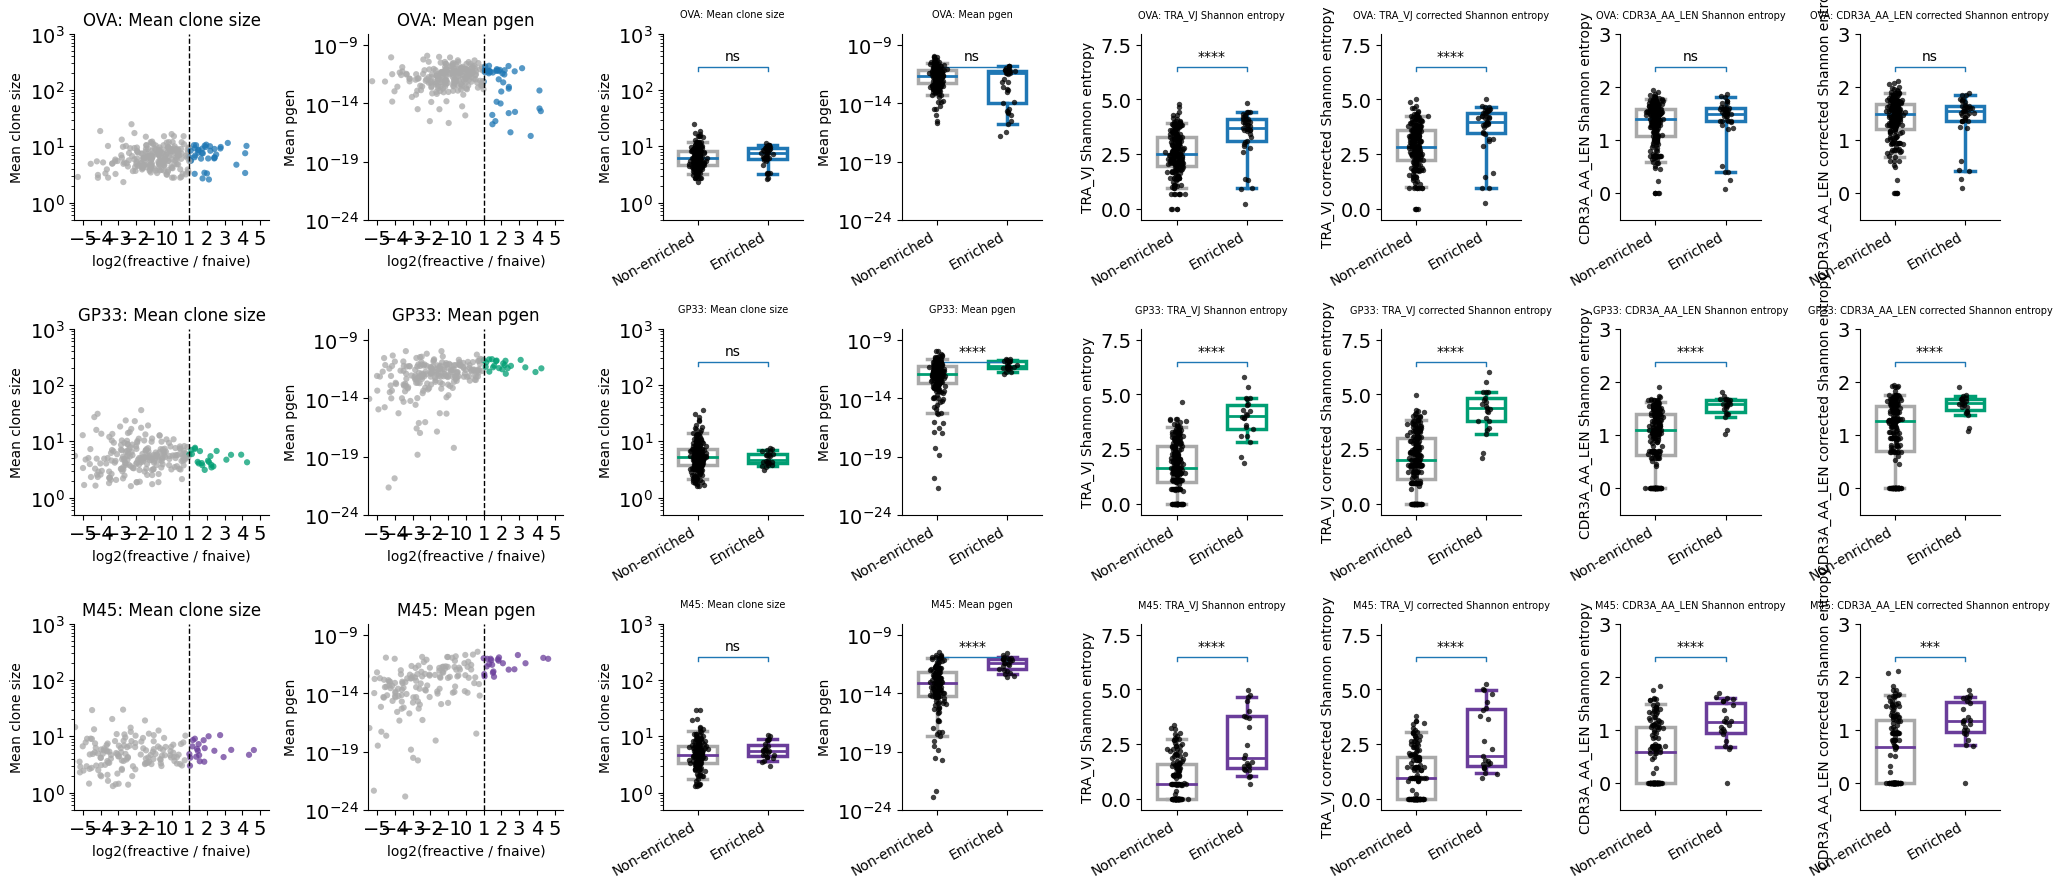

In [45]:
epitope_colors = {
    "OVA": "#1F77B4",
    "GP33": "#009E73",
    "M45": "#6A3D9A",
}


fig = diversity_analysis.plot_all_epitopes_generalized(
    df_enrich_all=df_enrich_all,
    paired_div_all=paired_div_all,
    stats_all=stats_all,
    epitopes=epitopes,

    enrich_col="trb_vj",
    paired_col="tra_vj",
    paired_cdr3_len_col="cdr3a_aa_len",

    epitope_colors=epitope_colors,
    non_enriched_color="darkgray",
    fc_threshold=2,
    axis_limits=axis_limits,

    # Panel dimensions
    scatter_width=3.2,
    box_width=2.3,
    subplot_height=3,

    # Boxplot appearance
    boxplot_width=0.55,
    box_linewidth=2.5,
    median_color=None,
    median_linewidth=2.0,

    # All observations
    point_color="black",
    point_size=15,
    point_alpha=0.75,
    point_jitter=0.045,

    whis=(5, 95),

    # Statistical annotation
    stat_label="stars",       # "stars", "p", or "both"
    stat_bracket_y=0.80,
    stat_text_y=0.84,
    title_y=1.06,

    group_order=(
        "Non-enriched",
        "Enriched",
    ),

    random_state=1,

    save_pdf=True,
    pdf_path = "./manuscript_figures/figure3_summary_tcr_enrichment_beta_fold_change.pdf"
)
paired_div_all.to_excel('./manuscript_figures/data_sheets/figure3_summary_tcr_enrichment_beta_fold_change.xlsx')

Generation probabilities

In [46]:
clone_df_final = df_tcr[df_tcr.isolated_specificity!='naive'].reset_index(drop=True).copy()

In [47]:
pgen_cols = ['pgen_cdr3_a_aa',
       'pgen_cdr3_b_aa']
	   
for col in pgen_cols:
    df_obs[col] = df_obs['TCR'].map(clone_df_final.set_index('tcr_id')[col])

df_obs['pgen_tcr'] = df_obs['pgen_cdr3_a_aa'] * df_obs['pgen_cdr3_b_aa']

#split obs df by epitope to match old code
df_list = []
epitope_list = ['OVA','GP33','M45']
for ep in epitope_list:
    temp = df_obs[df_obs.annotated_specificity==ep].reset_index(drop=True).copy()
    df_list.append(temp)

df_obs['tcr_id_nt'] = df_obs['IR_VJ_1_v_call'] + '_' + df_obs['IR_VJ_1_j_call'] + '_' + df_obs['IR_VJ_1_junction'] + '__' + df_obs['IR_VDJ_1_v_call'] + '_' + df_obs['IR_VDJ_1_j_call'] + '_' + df_obs['IR_VDJ_1_junction']

df_obs["annotated_specificity"] = (
    df_obs["TCR"]
    .map(
        df_tcr[df_tcr.annotated_specificity!='naive'].set_index("tcr_id")["annotated_specificity"]
    )
)
df_obs["annotated_specificity"] = df_obs["annotated_specificity"].fillna("below_threshold")

In [48]:
df_obs_react = df_obs[df_obs.annotated_specificity!='below_threshold'].reset_index(drop=True).copy()

nt:aa ratio

In [49]:
df_obs['nt_to_aa_ratio'] = (
    df_obs.groupby(['mouse', 'TCR'])['tcr_id_nt']
      .transform('nunique')
)
df_obs_react['nt_to_aa_ratio'] = (
    df_obs_react.groupby(['mouse', 'TCR'])['tcr_id_nt']
      .transform('nunique')
)

df_obs['nt_to_aa_ratio_total'] = (
    df_obs.groupby('TCR')['tcr_id_nt']
      .transform('nunique')
)
df_obs_react['nt_to_aa_ratio_total'] = (
    df_obs_react.groupby(['TCR'])['tcr_id_nt']
      .transform('nunique')
)
df_obs_react["shared_mouse"] = (
    df_obs_react.groupby("TCR")["mouse"]
    .transform("nunique")
)

df_deduplicated = df_obs_react.groupby('TCR').agg(
    TCR = ('TCR','first'),
    pgen_tcr = ('pgen_tcr','first'),
    nt_to_aa_ratio = ('nt_to_aa_ratio','max'),
    nt_to_aa_ratio_total = ('nt_to_aa_ratio_total','max'),
)

df_deduplicated['tcr_id'] = df_deduplicated['TCR']

df_tcr["nt_to_aa_ratio_total"] = (
    df_tcr["tcr_id"]
    .map(
        df_deduplicated.set_index("tcr_id")["nt_to_aa_ratio_total"]
    )
)

Plot nt:aa ratio

,epitope,comparison,p_raw,p_adj_holm_sidak,test,correction,stars
0,OVA,1 vs 2,1.504903e-31,4.514709e-31,Mann-Whitney U,Holm-Sidak within epitope,****
1,OVA,1 vs 3,1.387815e-09,2.775629e-09,Mann-Whitney U,Holm-Sidak within epitope,****
2,OVA,1 vs 4,3.891281e-02,3.891281e-02,Mann-Whitney U,Holm-Sidak within epitope,*
3,GP33,1 vs 2,1.579916e-18,4.739747e-18,Mann-Whitney U,Holm-Sidak within epitope,****
4,GP33,1 vs 3,2.803729e-05,5.607379e-05,Mann-Whitney U,Holm-Sidak within epitope,****
5,GP33,1 vs 4,8.745643e-02,8.745643e-02,Mann-Whitney U,Holm-Sidak within epitope,ns
6,M45,1 vs 2,1.259180e-39,3.777540e-39,Mann-Whitney U,Holm-Sidak within epitope,****
7,M45,1 vs 3,2.463365e-16,4.926730e-16,Mann-Whitney U,Holm-Sidak within epitope,****
8,M45,1 vs 4,1.630299e-04,1.630299e-04,Mann-Whitney U,Holm-Sidak within epitope,***


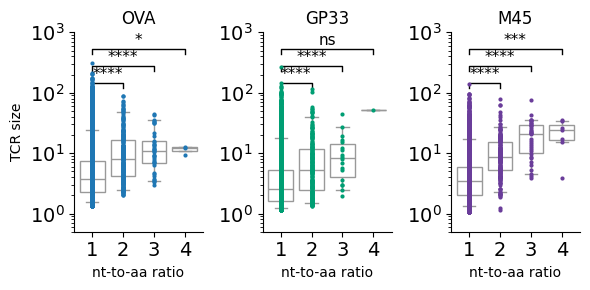

In [50]:
def p_to_stars(p):
    if p < 1e-4:
        return "****"
    elif p < 1e-3:
        return "***"
    elif p < 1e-2:
        return "**"
    elif p < 0.05:
        return "*"
    return "ns"
    
df_plot = df_obs_react.groupby(['mouse','TCR']).agg(
    TCR = ('TCR','first'),
    tcr_size = ('norm_TCR_expansion','first'),
    nt_to_aa_ratio = ('nt_to_aa_ratio','first'),
    annotated_specificity = ('annotated_specificity', 'first'),
)

import scipy.stats as st

epitope_list = ['OVA', 'GP33', 'M45']
color_list = ['#1F77B4', '#009E73', '#6A3D9A']

from scipy import stats as st
from statsmodels.stats.multitest import multipletests

def add_sig_bracket_log(ax, x0, x1, y, text, h_factor=1.2):
    ax.plot(
        [x0, x0, x1, x1],
        [y, y * h_factor, y * h_factor, y],
        lw=1,
        color="black",
    )
    ax.text(
        (x0 + x1) / 2,
        y * h_factor * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
    )


fig, ax = plt.subplots(
    nrows=1,
    ncols=len(epitope_list),
    figsize=(2 * len(epitope_list), 3),
    sharey=True,
)

if len(epitope_list) == 1:
    ax = [ax]

stats_list = []

ref = 1
targets = [2, 3, 4]
order = [1, 2, 3, 4]

for col, ep in enumerate(epitope_list):
    a = ax[col]

    df = (
        df_plot[df_plot["annotated_specificity"] == ep]
        .copy()
    )

    df = df[
        df["nt_to_aa_ratio"].isin(order)
        & df["tcr_size"].notna()
    ].copy()

    sns.stripplot(
        data=df,
        x="nt_to_aa_ratio",
        y="tcr_size",
        order=order,
        ax=a,
        color=color_list[col],
        s=3,
        jitter=0,
    )

    sns.boxplot(
        data=df,
        x="nt_to_aa_ratio",
        y="tcr_size",
        order=order,
        ax=a,
        fliersize=0,
        color="white",
        whis = (5,95),
    )

    a.set_yscale("log")
    a.set_ylim(0.5, 1000)

    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(False)

    ref_vals = df.loc[
        df["nt_to_aa_ratio"] == ref,
        "tcr_size",
    ].dropna()

    raw_pvals = []
    valid_targets = []

    for target in targets:
        target_vals = df.loc[
            df["nt_to_aa_ratio"] == target,
            "tcr_size",
        ].dropna()

        if len(ref_vals) == 0 or len(target_vals) == 0:
            p = np.nan
        else:
            _, p = st.mannwhitneyu(
                ref_vals,
                target_vals,
                alternative="two-sided",
            )

        raw_pvals.append(p)
        valid_targets.append(target)

    raw_pvals = np.array(raw_pvals, dtype=float)
    finite_mask = np.isfinite(raw_pvals)

    p_adj = np.full(len(raw_pvals), np.nan)

    if finite_mask.sum() > 0:
        p_adj[finite_mask] = multipletests(
            raw_pvals[finite_mask],
            method="holm-sidak",
        )[1]

    x_map = {
        label: pos
        for label, pos in zip(order, range(len(order)))
    }

    y_start = 120
    y_step = 1.9

    for j, target in enumerate(valid_targets):
        p_corr = p_adj[j]

        stars = (
            p_to_stars(p_corr)
            if np.isfinite(p_corr)
            else "NA"
        )

        stats_list.append({
            "epitope": ep,
            "comparison": f"{ref} vs {target}",
            "p_raw": raw_pvals[j],
            "p_adj_holm_sidak": p_corr,
            "test": "Mann-Whitney U",
            "correction": "Holm-Sidak within epitope",
            "stars": stars,
        })

        if np.isfinite(p_corr):
            y = y_start * (y_step ** j)

            add_sig_bracket_log(
                ax=a,
                x0=x_map[ref],
                x1=x_map[target],
                y=y,
                text=stars,
            )

    a.set_title(ep)
    a.set_xlabel("nt-to-aa ratio")

    if col == 0:
        a.set_ylabel("TCR size")
    else:
        a.set_ylabel("")

    a.tick_params(axis="x", labelsize=14)
    a.tick_params(axis="y", labelsize=14,  labelleft=True)

fig.tight_layout()
fig.savefig('./manuscript_figures/figure3_clone_size_vs_nt_to_aa_all_epitopes.pdf')
stats_df = pd.DataFrame(stats_list)
display(stats_df)

## Bin pgen into high and low by median

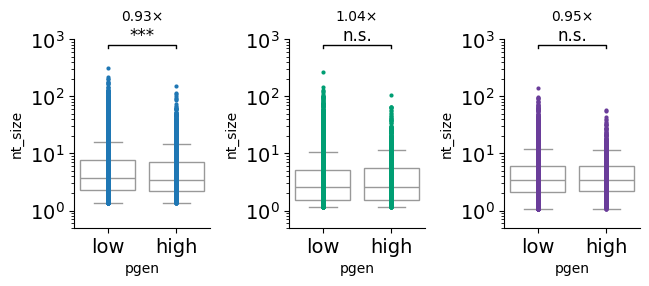

In [51]:
from scipy.stats import mannwhitneyu

#annotate tcr_id_nt counts
df_obs['tcr_id_nt_expansion'] = df_obs.groupby(['mouse','tcr_id_nt'])['tcr_id_nt'].transform("size")

df_obs["norm_TCR_expansion_nt"] = (
    df_obs["tcr_id_nt_expansion"] /
    df_obs["size_factor"].fillna(0)
) + 1

epitope_list = ['OVA', 'GP33', 'M45']
color_list = ['#1F77B4', '#009E73', '#6A3D9A']
ncols = len(epitope_list)

fig, ax = plt.subplots(ncols=ncols, figsize=(2.2 * ncols, 3))

if ncols == 1:
    ax = [ax]

for i, ep in enumerate(epitope_list):
    df = df_obs[df_obs.annotated_specificity == ep].copy()

    z = (df['pgen_tcr'] - df['pgen_tcr'].mean()) / df['pgen_tcr'].std()
    df['bin_pgen_tcr'] = np.where(z >= 0, 'high', 'low')

    df_plot = (
        df.groupby('tcr_id_nt')
        .agg(
            nt_size=('norm_TCR_expansion_nt', 'max'),
            pgen=('bin_pgen_tcr', 'first'),
        )
        .reset_index()
    )

    sns.stripplot(
        data=df_plot, x='pgen', y='nt_size',
        order=['low', 'high'],
        ax=ax[i], color=color_list[i], s=3, jitter=0
    )

    sns.boxplot(
        data=df_plot, x='pgen', y='nt_size',
        order=['low', 'high'],
        ax=ax[i], fliersize=0, color='white'
    )
    
    low = df_plot.loc[df_plot['pgen'] == 'low', 'nt_size'].dropna()
    high = df_plot.loc[df_plot['pgen'] == 'high', 'nt_size'].dropna()
    
    if len(low) > 0 and len(high) > 0:
        stat, p = mannwhitneyu(low, high, alternative='two-sided')

        if p < 0.001:
            p_text = '***'
        elif p < 0.01:
            p_text = '**'
        elif p < 0.05:
            p_text = '*'
        else:
            p_text = 'n.s.'

        y = 700
        ax[i].plot([0, 0, 1, 1], [y, y * 1.12, y * 1.12, y], lw=1, c='black')
        ax[i].text(
            0.5, y * 1.18, p_text,
            ha='center', va='bottom', fontsize=12
        )
        
    # Mean fold change
    fc = high.mean() / low.mean()
    # fold change above significance
    ax[i].text(
        0.5, y*2.7,
        f'{fc:.2f}×',
        ha='center', va='bottom', fontsize=10
    )

    ax[i].set_yscale('log')
    ax[i].set_ylim(0.5, 1000)

    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].grid(False)

    ax[i].tick_params(axis='x', labelsize=14)
    ax[i].tick_params(axis='y', labelsize=14)

fig.tight_layout()
fig.savefig('./manuscript_figures/figure3_clone_size_vs_pgen_all.pdf')

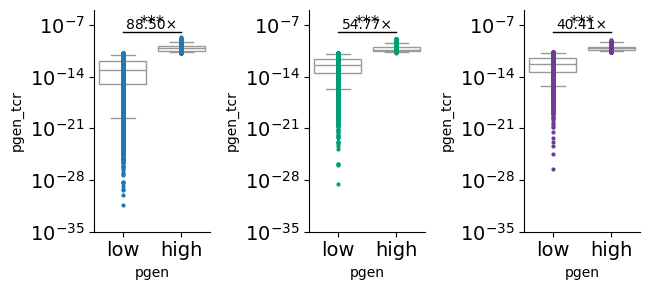

In [52]:
epitope_list = ['OVA', 'GP33', 'M45']
color_list = ['#1F77B4', '#009E73', '#6A3D9A']
ncols = len(epitope_list)

fig, ax = plt.subplots(ncols=ncols, figsize=(2.2 * ncols, 3))

if ncols == 1:
    ax = [ax]

for i, ep in enumerate(epitope_list):
    df = df_obs.loc[(df_obs.annotated_specificity == ep) & (df_obs.pgen_tcr>0)].copy()

    z = (df['pgen_tcr'] - df['pgen_tcr'].mean()) / df['pgen_tcr'].std()
    df['bin_pgen_tcr'] = np.where(z >= 0, 'high', 'low')

    df_plot = (
        df.groupby('tcr_id_nt')
        .agg(
            pgen_tcr=('pgen_tcr', 'first'),
            pgen=('bin_pgen_tcr', 'first'),
        )
        .reset_index()
    )

    sns.stripplot(
        data=df_plot, x='pgen', y='pgen_tcr',
        order=['low', 'high'],
        ax=ax[i], color=color_list[i], s=3, jitter=0
    )

    sns.boxplot(
        data=df_plot, x='pgen', y='pgen_tcr',
        order=['low', 'high'],
        ax=ax[i], fliersize=0, color='white',
        whis = (5,95),
    )
    
    low = df_plot.loc[df_plot['pgen'] == 'low', 'pgen_tcr'].dropna()
    high = df_plot.loc[df_plot['pgen'] == 'high', 'pgen_tcr'].dropna()
    
    if len(low) > 0 and len(high) > 0:
        stat, p = mannwhitneyu(low, high, alternative='two-sided')

        if p < 0.001:
            p_text = '***'
        elif p < 0.01:
            p_text = '**'
        elif p < 0.05:
            p_text = '*'
        else:
            p_text = 'n.s.'

        y = 10**-8
        ax[i].plot([0, 0, 1, 1], [y, y * 1.12, y * 1.12, y], lw=1, c='black')
        ax[i].text(
            0.5, y * 1.18, p_text,
            ha='center', va='bottom', fontsize=12
        )
        
    # Mean fold change
    fc = high.mean() / low.mean()
    # fold change above significance
    ax[i].text(
        0.5, y*1.2,
        f'{fc:.2f}×',
        ha='center', va='bottom', fontsize=10
    )

    ax[i].set_yscale('log')
    ax[i].set_ylim(10**-35, 10**-5)

    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].grid(False)

    ax[i].tick_params(axis='x', labelsize=14)
    ax[i].tick_params(axis='y', labelsize=14)

fig.tight_layout()
fig.savefig('./manuscript_figures/figure3_pgen_bin_vs_pgen_all.pdf')

-

-

-

-

# Figure 4

Kmer entropy

In [53]:
import paired_chain_shannon_analysis_log2fc as diversity_analysis

epitopes = [
    "OVA",
    "GP33",
    "M45",
]

df_enrich_all, paired_div_all, stats_all = (
    diversity_analysis.run_epitope_analysis_generalized(
        df_tcr=df_tcr,
        df_naive_tcr=df_naive_tcr,
        epitopes=epitopes,

        enrich_col="trb_vj",
        paired_col="tra_vj",
        paired_cdr3_len_col="cdr3a_aa_len",

        specificity_col="annotated_specificity",
        clone_size_col="norm_TCR_expansion",
        pgen_col="pgen_cdr3_ab",

        fc_threshold=2,
        eps=1e-10,
        naive_missing_count=1,

        group_order=(
            "Non-enriched",
            "Enriched",
        ),

        # Holm correction across epitopes,
        # applied independently for each metric
        p_adjust="holm-sidak",
    )
)

kmer_ylim_dict = {
    # Full, untrimmed CDR3 k-mers
    "kmer_full_shannon_entropy": (2, 6),
    "kmer_full_shannon_entropy_corrected": (2, 6),

    # Trimmed CDR3 k-mers
    "kmer_trimmed_shannon_entropy": (1, 6),
    "kmer_trimmed_shannon_entropy_corrected": (0, 6),

    # Complete CDR3 sequence diversity
    "cdr3_shannon_entropy": (0, 6),
    "cdr3_shannon_entropy_corrected": (0, 6),
}


3mer calculation

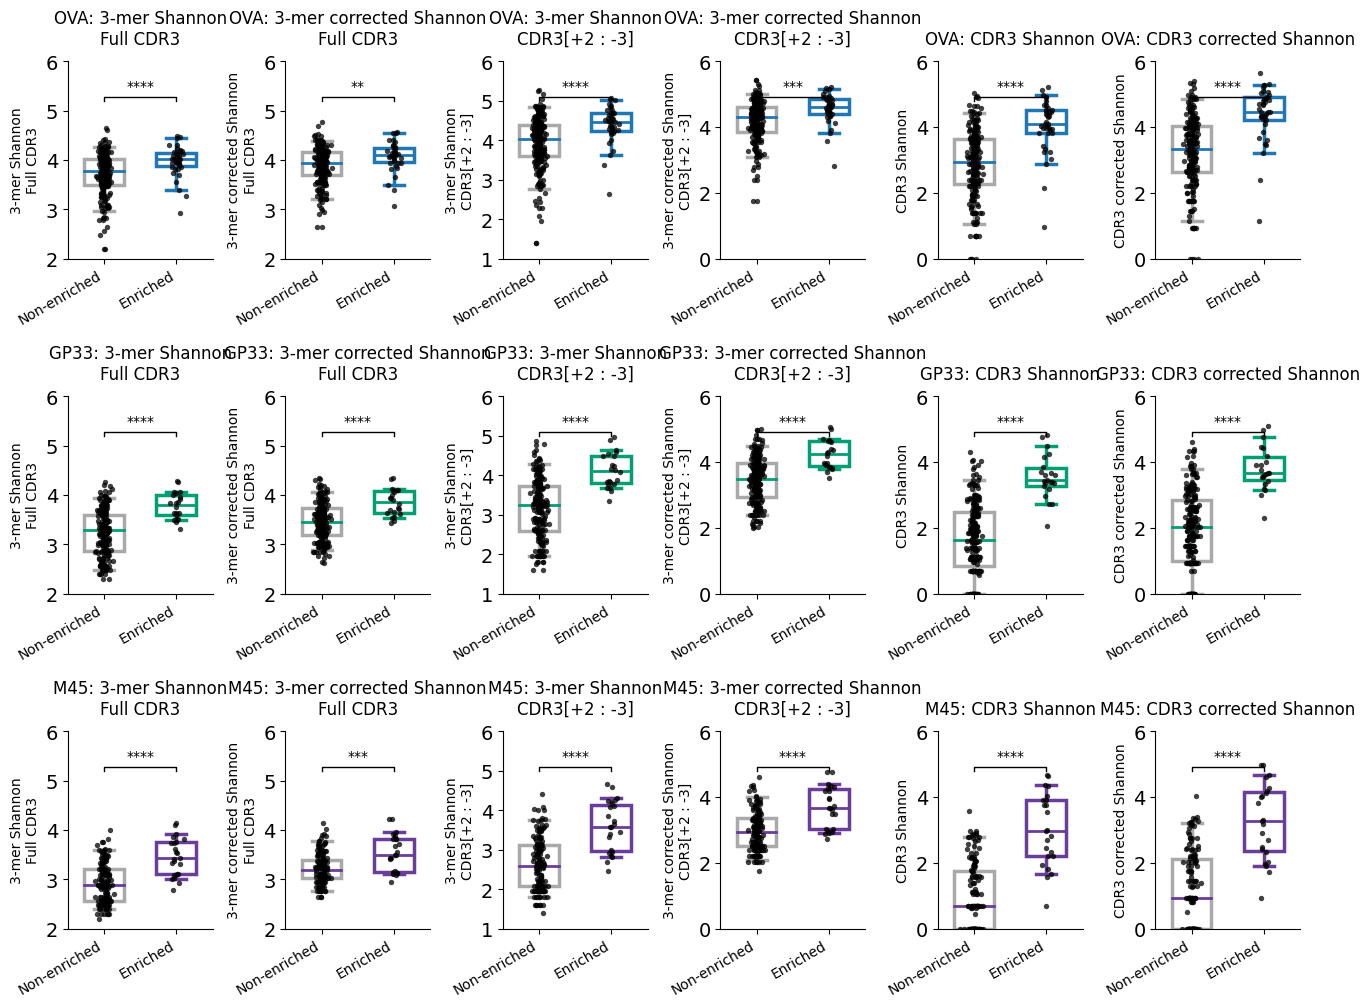

In [54]:
import kmer_cdr3_shannon_analysis as kmer_div

epitopes = [
    "OVA",
    "GP33",
    "M45",
]

epitope_colors = {
    "OVA": "#1F77B4",
    "GP33": "#009E73",
    "M45": "#6A3D9A",
}

results = kmer_div.plot_kmer_and_cdr3_shannon_all_epitopes(
    df_tcr=df_tcr,
    df_enrich_all=df_enrich_all,
    epitopes=epitopes,
    enrich_col="trb_vj",
    paired_col="tra_vj",
    cdr3_col="cdr3b_aa",
    enrich_col_enrich="gene_recombination",
    epitope_col_tcr="annotated_specificity",
    epitope_col_enrich="epitope",
    group_col="enrichment_group",

    group_order=(
        "Non-enriched",
        "Enriched",
    ),
    xlim=(0.5, 2.5),
    
    # K-mer settings
    k=3,

    # Full CDR3 is always calculated separately.
    # These settings define the additional trimmed analysis.
    trim_start=2,
    trim_end=3,

    # Include complete-CDR3 metrics
    include_cdr3=True,

    # Paired-chain metrics are calculated regardless;
    # set True to include them in the figure.
    include_paired=False,

    epitope_colors=epitope_colors,
    non_enriched_color="darkgray",
    ylim_dict=kmer_ylim_dict,

    # Panel dimensions
    box_width=2.2,
    subplot_height=3.4,

    # Boxplot appearance
    boxplot_width=0.55,
    box_linewidth=2.5,
    median_color=None,
    median_linewidth=2.0,

    # All observations
    point_color="black",
    point_size=15,
    point_alpha=0.75,
    point_jitter=0.045,

    whis=(5, 95),

    # Statistical annotation
    stat_label="stars",       # "stars", "p", or "both"
    stat_bracket_y=0.80,
    stat_text_y=0.84,
    title_y=1.06,

    random_state=1,

    # PDF output
    save_pdf=True, #'./figure_drafts/figure_4_trb_vj_kmer3_diversity.pdf'
    pdf_path=('./manuscript_figures/figure4_trb_vj_kmer3_diversity.pdf'),

    show=True,
)
results['div_all'].to_excel('./manuscript_figures/data_sheets/figure_4_trb_vj_kmer3_diversity.xlsx')

2mer calculation

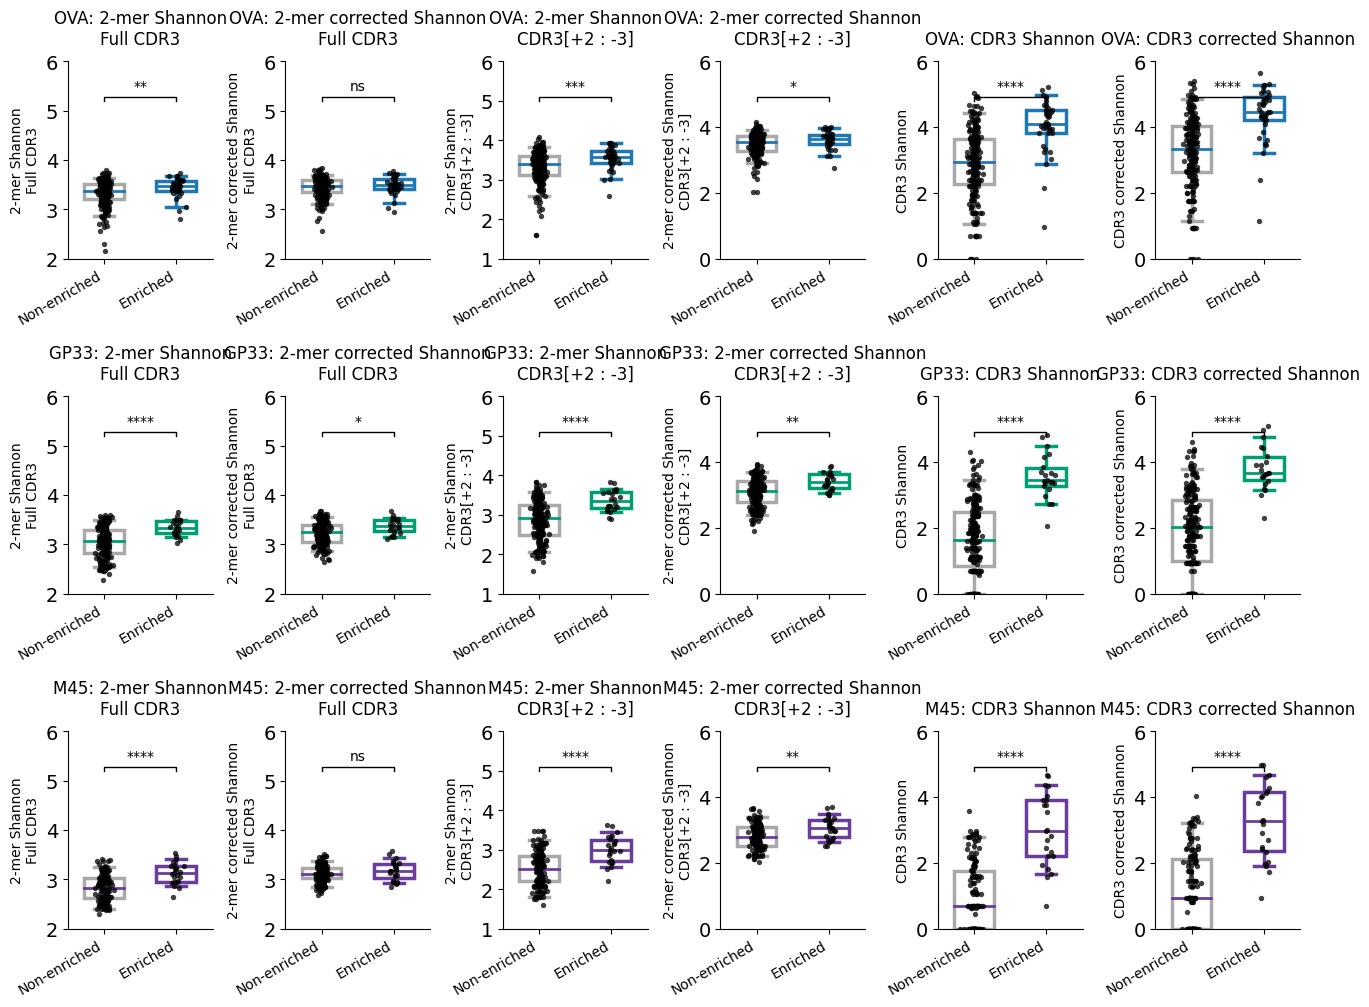

In [55]:
results = kmer_div.plot_kmer_and_cdr3_shannon_all_epitopes(
    df_tcr=df_tcr,
    df_enrich_all=df_enrich_all,
    epitopes=epitopes,
    enrich_col="trb_vj",
    paired_col="tra_vj",
    cdr3_col="cdr3b_aa",
    enrich_col_enrich="gene_recombination",
    epitope_col_tcr="annotated_specificity",
    epitope_col_enrich="epitope",
    group_col="enrichment_group",

    group_order=(
        "Non-enriched",
        "Enriched",
    ),
    xlim=(0.5, 2.5),
    
    # K-mer settings
    k=2,

    # Full CDR3 is always calculated separately.
    # These settings define the additional trimmed analysis.
    trim_start=2,
    trim_end=3,

    # Include complete-CDR3 metrics
    include_cdr3=True,

    # Paired-chain metrics are calculated regardless;
    # set True to include them in the figure.
    include_paired=False,

    epitope_colors=epitope_colors,
    non_enriched_color="darkgray",
    ylim_dict=kmer_ylim_dict,

    # Panel dimensions
    box_width=2.2,
    subplot_height=3.4,

    # Boxplot appearance
    boxplot_width=0.55,
    box_linewidth=2.5,
    median_color=None,
    median_linewidth=2.0,

    # All observations
    point_color="black",
    point_size=15,
    point_alpha=0.75,
    point_jitter=0.045,

    whis=(5, 95),

    # Statistical annotation
    stat_label="stars",       # "stars", "p", or "both"
    stat_bracket_y=0.80,
    stat_text_y=0.84,
    title_y=1.06,

    random_state=1,

    # PDF output
    save_pdf=True, #'./figure_drafts/figure_4_trb_vj_kmer3_diversity.pdf'
    pdf_path=('./manuscript_figures/figure4_trb_vj_kmer2_diversity.pdf'),

    show=True,
)
results['div_all'].to_excel('./manuscript_figures/data_sheets/figure_4_trb_vj_kmer2_diversity.xlsx')

Positional flexibility

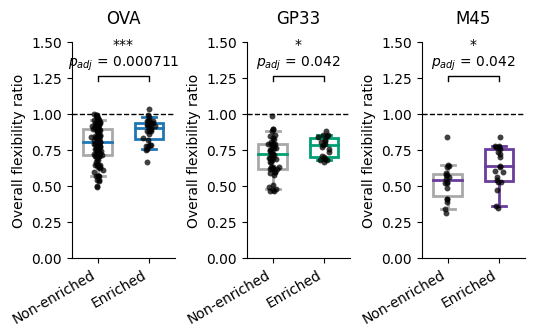

In [56]:
import cdr3_overall_flexibility_ratio as cdr3_flex

#settings
cfg = cdr3_flex.CDR3FlexConfig(
    epi_cdr3_col="cdr3b_aa",
    bg_cdr3_col="cdr3b_aa",

    epi_vj_col="trb_vj",
    bg_vj_col="trb_vj",

    ann_vj_col="gene_recombination",
    ann_status_col="enrichment_group",

    epi_context_cols=("annotated_specificity",),
    ann_context_cols=("epitope",),

    trim_left=2,
    trim_right=3,

    min_epi_n=8,
    min_bg_n=20,

    entropy_method="miller_madow",

    # Choose "maximum" or "observed"
    entropy_normalization="maximum",

    equal_size_subsampling=False,
    random_state=1,
)

# calculations
metrics_df, skipped_df = (
    cdr3_flex.run_cdr3b_flexibility_analysis(
        df_epi=df_tcr[~df_tcr.annotated_specificity.isin(['naive','M38'])].reset_index(drop=True),
        df_bg=df_tcr[df_tcr.annotated_specificity=='naive'].reset_index(drop=True),
        df_ann=df_enrich_all,
        cfg=cfg,
    )
)
# merge data
vj_summary = cdr3_flex.aggregate_metrics_to_vj(
    metrics_df,
    context_cols=("annotated_specificity",),
    weight_by_sequence_count=True,
)

results  = (
    cdr3_flex.plot_flexibility_ratio_by_context(
        dataframe=vj_summary,
        context_col="annotated_specificity",
        context_order=epitope_list,
        context_colors=epitope_colors,
    
        status_order=(
            "Non-enriched",
            "Enriched",
        ),
    
        ylim=(0, 1.5),
        reference_line=1,
    
        p_adjust="holm-sidak",
        stat_label="both",
        
        # Width and height of each subplot in inches
       subplot_size=(1.8, 3.5)
    )
)
fig, ax = results["fig"], results["axes"]

for a in fig.axes:
    a.tick_params(axis="y", labelsize=14)
fig.savefig('./manuscript_figures/figure4_trb_vj_position_entropy.pdf')

Logoplots

In [57]:
fr_ova = ['TRBV31_TRBJ1-6','TRBV17_TRBJ2-2']
fr_gp33 = ['TRBV13-3_TRBJ2-1','TRBV1_TRBJ2-4']
fr_m45 = ['TRBV12-1_TRBJ2-7','TRBV13-2_TRBJ2-7']

df_inputs = [
    # ========================================================
    # OVA
    # ========================================================
    (
        "OVA enriched",
        df_tcr.loc[
            df_tcr["annotated_specificity"].eq("OVA")
            & df_tcr["trb_vj"].eq(fr_ova[0])
        ].copy(),
    ),
    (
        "OVA baseline enriched",
        df_naive_tcr.loc[
            df_naive_tcr["trb_vj"].eq(fr_ova[0])
        ].copy(),
    ),
    (
        "OVA non-enriched",
        df_tcr.loc[
            df_tcr["annotated_specificity"].eq("OVA")
            & df_tcr["trb_vj"].eq(fr_ova[1])
        ].copy(),
    ),
    (
        "OVA baseline non-enriched",
        df_naive_tcr.loc[
            df_naive_tcr["trb_vj"].eq(fr_ova[1])
        ].copy(),
    ),

    # ========================================================
    # GP33
    # ========================================================
    (
        "GP33 enriched",
        df_tcr.loc[
            df_tcr["annotated_specificity"].eq("GP33")
            & df_tcr["trb_vj"].eq(fr_gp33[0])
        ].copy(),
    ),
    (
        "GP33 baseline enriched",
        df_naive_tcr.loc[
            df_naive_tcr["trb_vj"].eq(fr_gp33[0])
        ].copy(),
    ),

    (
        "GP33 non-enriched",
        df_tcr.loc[
            df_tcr["annotated_specificity"].eq("GP33")
            & df_tcr["trb_vj"].eq(fr_gp33[1])
        ].copy(),
    ),
    (
        "GP33 baseline non-enriched",
        df_naive_tcr.loc[
            df_naive_tcr["trb_vj"].eq(fr_gp33[1])
        ].copy(),
    ),

    # ========================================================
    # M45
    # ========================================================
    (
        "M45 enriched",
        df_tcr.loc[
            df_tcr["annotated_specificity"].eq("M45")
            & df_tcr["trb_vj"].eq(fr_m45[0])
        ].copy(),
    ),
    (
        "M45 baseline enriched",
        df_naive_tcr.loc[
            df_naive_tcr["trb_vj"].eq(fr_m45[0])
        ].copy(),
    ),
    (
        "M45 non-enriched",
        df_tcr.loc[
            df_tcr["annotated_specificity"].eq("M45")
            & df_tcr["trb_vj"].eq(fr_m45[1])
        ].copy(),
    ),
    (
        "M45 baseline non-enriched",
        df_naive_tcr.loc[
            df_naive_tcr["trb_vj"].eq(fr_m45[1])
        ].copy(),
    ),
]

/Users/yang.an/PhD/Straub_An_et_al_2026_The-total-epitope-specific-T-cell-receptor-solution-space/analysis scripts/cdr3_logo_epitope_baseline_matched_length.py:586: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


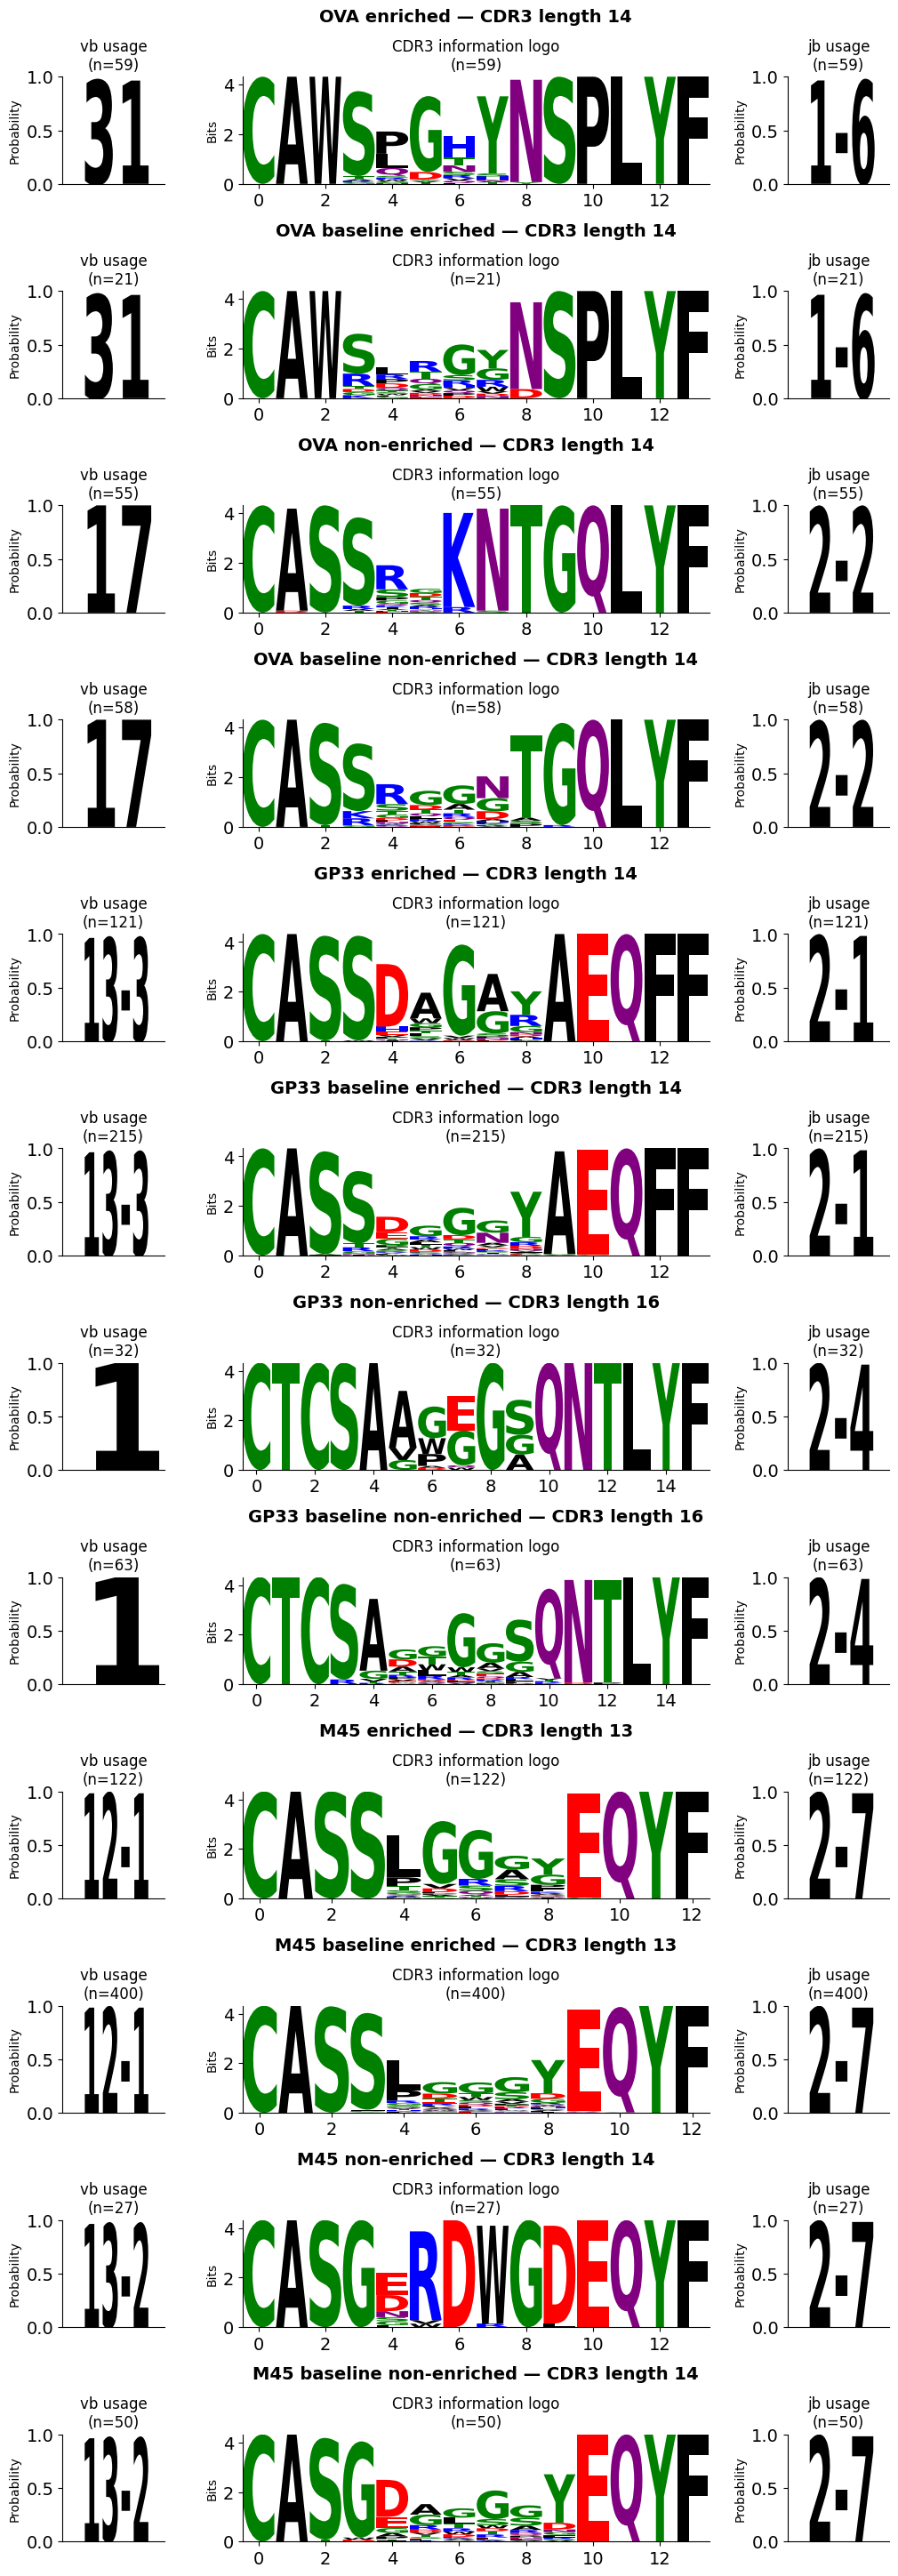

In [58]:
import cdr3_logo_epitope_baseline_matched_length as tlp

fig, logo_results = tlp.plot_cdr3_logo_multi(
    df_inputs=df_inputs,
    cdr3_col="cdr3b_aa",
    v_col="vb",
    j_col="jb",
    length_mode="most_common",
    length=None,
    max_v_genes=15,
    max_j_genes=15,
    figsize_per_df=(12, 3),
    show_probability_logo=False,
    save_path="./manuscript_figures/figure4_cdr3_logo_multiplots.pdf",
)

Median V-J group for calculated entropy

In [59]:
col_vj = 'paired_shannon_entropy_corrected'
col_len = 'paired_cdr3_len_shannon_entropy_corrected'

In [60]:
value_col = 'paired_shannon_entropy_corrected'
return_col = "trb_vj"
counts_col = "n_tcr"

size_select = [0,0,0]
fr_ova = []
fr_gp33 = []
fr_m45 = []

for i,ep in enumerate(epitope_list):
    filtered = paired_div_all.loc[
        (paired_div_all["epitope"] == ep)
        & (paired_div_all["enrichment_group"] == "Enriched")
        & (paired_div_all["n_tcr"] > size_select[i])
    ].dropna(subset=[value_col, counts_col])

    if filtered.empty:
        print(f"{ep}: no valid rows")
        continue

    q1 = filtered[value_col].quantile(0.35) #425
    q3 = filtered[value_col].quantile(0.65) #675

    # Keep rows within Q1–Q3, including the boundaries
    within_iqr = filtered.loc[
        filtered[value_col].between(q1, q3, inclusive="both")
    ]
    #select equal size
    within_iqr = within_iqr.loc[(within_iqr["n_tcr"] < 200)]# & (within_iqr["n_tcr"] > 50)]

    selected_idx = within_iqr[counts_col].idxmax()
    selected_row = within_iqr.loc[selected_idx]

    print(
        f"{ep}: "
        f"Q1–Q3 = {q1:.4g}–{q3:.4g}, "
        #f"selected {value_col} = {selected_row[value_col]:.4g}, "
        #f"{return_col} = {selected_row[return_col]}, "
        #f"{counts_col} = {selected_row[counts_col]}"
    )
    #if ep == 'OVA':
    #    fr_ova.append(selected_row['trb_vj'])
    #elif ep == 'GP33':
    #    fr_gp33.append(selected_row['trb_vj'])
    #else:
    #    fr_m45.append(selected_row['trb_vj'])

value_col = 'paired_shannon_entropy_corrected'
return_col = "trb_vj"
counts_col = "n_tcr"

for ep in epitope_list:
    filtered = paired_div_all.loc[
        (paired_div_all["epitope"] == ep)
        & (paired_div_all["enrichment_group"] == "Non-enriched")
        & (paired_div_all["n_tcr"] > size_select[i])
    ].dropna(subset=[value_col, counts_col])

    if filtered.empty:
        print(f"{ep}: no valid rows")
        continue

    q1 = filtered[value_col].quantile(0.35) #425
    q3 = filtered[value_col].quantile(0.65) #575

    # Keep rows within Q1–Q3, including the boundaries
    within_iqr = filtered.loc[
        filtered[value_col].between(q1, q3, inclusive="both")
    ]
    #select equal size
    #within_iqr = within_iqr.loc[(within_iqr["n_tcr"] < 300)]# & (within_iqr["n_tcr"] > 50)]

    selected_idx = within_iqr[counts_col].idxmax()
    selected_row = within_iqr.loc[selected_idx]

    print(
        f"{ep}: "
        f"Q1–Q3 = {q1:.4g}–{q3:.4g}, "
        #f"selected {value_col} = {selected_row[value_col]:.4g}, "
        #f"{return_col} = {selected_row[return_col]}, "
        #f"{counts_col} = {selected_row[counts_col]}"
    )
    #if ep == 'OVA':
    #    fr_ova.append(selected_row['trb_vj'])
    #elif ep == 'GP33':
    #    fr_gp33.append(selected_row['trb_vj'])
    #else:
    #    fr_m45.append(selected_row['trb_vj'])

OVA: Q1–Q3 = 3.828–4.216, 
GP33: Q1–Q3 = 3.997–4.624, 
M45: Q1–Q3 = 1.613–3.674, 
OVA: Q1–Q3 = 2.509–3.331, 
GP33: Q1–Q3 = 1.632–2.554, 
M45: Q1–Q3 = 0–1.432, 


Selected within IQR (0.35-0.65)

In [61]:
fr_ova = ['TRBV31_TRBJ1-3','TRBV12-2_TRBJ2-5']
fr_gp33 = ['TRBV29_TRBJ2-2','TRBV4_TRBJ1-1']
fr_m45 = ['TRBV17_TRBJ1-1','TRBV2_TRBJ2-4']

In [62]:
ova_div = paired_div_all[paired_div_all.epitope=='OVA']
gp33_div = paired_div_all[paired_div_all.epitope=='GP33']
m45_div = paired_div_all[paired_div_all.epitope=='M45']

print(ova_div[ova_div.trb_vj.isin(fr_ova)].paired_shannon_entropy_corrected)
print(gp33_div[gp33_div.trb_vj.isin(fr_gp33)].paired_shannon_entropy_corrected)
print(m45_div[m45_div.trb_vj.isin(fr_m45)].paired_shannon_entropy_corrected)

34     2.755023
205    4.150333
Name: paired_shannon_entropy_corrected, dtype: float64
414    4.569449
453    1.705112
Name: paired_shannon_entropy_corrected, dtype: float64
553    3.627423
614    0.215254
Name: paired_shannon_entropy_corrected, dtype: float64


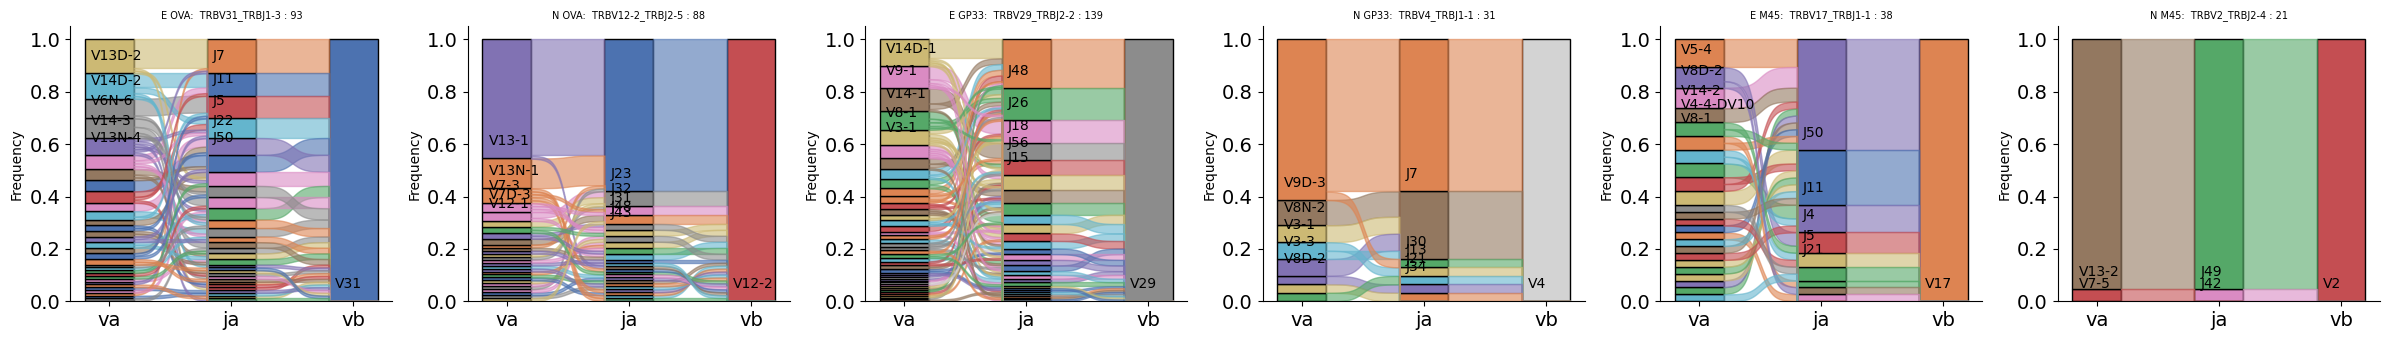

In [63]:
from repertoire_analysis import plt_vdj_usage_sc

framework_list = fr_ova + fr_gp33 + fr_m45
enriched_cat = ['E','N','E','N','E','N']
ep_cat = ['OVA','OVA','GP33','GP33','M45','M45']

ncols = len(framework_list)
fig, ax = plt.subplots(ncols = ncols, figsize = (ncols*4, 3.5))
                      
for i, fr in enumerate(framework_list):
    df = df_tcr.loc[(df_tcr.annotated_specificity==ep_cat[i]) & (df_tcr.trb_vj==fr)].reset_index(drop=True).copy()
    df['size_norm'] = 1
    counts = len(df)
    
    plt_vdj_usage_sc(
            df,
            vdj_cols=["va","ja", "vb"],
            normalize_to="size_norm",
            max_segments=None,
            max_labelled_segments=5,
            max_ribbons=None,
            full_combination=False,
            ax = ax[i]
        )
    ax[i].set_title(f"{enriched_cat[i]} {ep_cat[i]}:  {fr} : {counts}", fontsize = 7)
    ax[i].set_ylabel('Frequency')
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(axis='x', which='major', labelsize=14)
    ax[i].tick_params(axis='y', which='major', labelsize=14)

fig.tight_layout()
fig.savefig('./manuscript_figures/figure4_vdj_ribbon_enriched_v_non_quantile_selection.pdf')

CDR3 length

In [64]:

def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)
    
def plot_cdr3_spectratype_overlay(
    df1,
    df2,
    length_col="cdr3b_aa_len",
    label1="Group 1",
    label2="Group 2",
    color1="grey",
    color2="tab:blue",
    normalize=True,
    figsize=(3.5, 3.5),
    marker="o",
    linewidth=2,
    markersize=5,
):
    fig, ax = plt.subplots(figsize=figsize)

    # Common integer x-axis
    lengths = np.arange(
        min(df1[length_col].min(), df2[length_col].min()),
        max(df1[length_col].max(), df2[length_col].max()) + 1,
    )

    def get_distribution(df):
        counts = (
            df[length_col]
            .dropna()
            .astype(int)
            .value_counts()
            .reindex(lengths, fill_value=0)
            .sort_index()
        )

        if normalize:
            counts = counts / counts.sum()

        return counts

    dist1 = get_distribution(df1)
    dist2 = get_distribution(df2)

    ax.plot(
        lengths,
        dist1.values,
        "-o",
        color=color1,
        lw=linewidth,
        ms=markersize,
        label=label1,
    )

    ax.plot(
        lengths,
        dist2.values,
        "-o",
        color=color2,
        lw=linewidth,
        ms=markersize,
        label=label2,
    )

    ax.set_xticks([10,11,12,13,14,15,16,17,18])
    ax.set_xlim(9.2,18.8)
    ax.set_ylim(0,1)

    ax.set_xlabel("CDR3 length (AA)")
    ax.set_ylabel("Fraction" if normalize else "Count")
    

    ax.legend(frameon=False, fontsize = 7)

    style_axis(ax)
    ax.tick_params(axis='x', which='major', labelsize=14)
    ax.tick_params(axis='y', which='major', labelsize=16)

    fig.tight_layout()

    return fig

In [65]:
def plot_cdr3_spectratype_bars(
    df1,
    df2,
    length_col="cdr3b_aa_len",
    label1="Group 1",
    label2="Group 2",
    color1="grey",
    color2="tab:blue",
    normalize=True,
    figsize=(3.5, 3.5),
    bar_width=0.32,
    alpha=0.85,
):
    fig, ax = plt.subplots(figsize=figsize)

    # Common integer x-axis
    lengths = np.arange(
        int(min(df1[length_col].min(), df2[length_col].min())),
        int(max(df1[length_col].max(), df2[length_col].max())) + 1,
    )

    def get_distribution(df):
        counts = (
            df[length_col]
            .dropna()
            .astype(int)
            .value_counts()
            .reindex(lengths, fill_value=0)
            .sort_index()
            .astype(float)
        )

        if normalize and counts.sum() > 0:
            counts = counts / counts.sum()

        return counts

    dist1 = get_distribution(df1)
    dist2 = get_distribution(df2)

    # Side-by-side narrow bars
    ax.bar(
        lengths - bar_width / 2,
        dist1.values,
        width=bar_width,
        color=color1,
        alpha=alpha,
        label=label1,
        linewidth=0,
    )

    ax.bar(
        lengths + bar_width / 2,
        dist2.values,
        width=bar_width,
        color=color2,
        alpha=alpha,
        label=label2,
        linewidth=0,
    )

    ax.set_xticks([10, 11, 12, 13, 14, 15, 16, 17, 18])
    ax.set_xlim(9.2, 18.8)

    if normalize:
        ax.set_ylim(0, 1)

    ax.set_xlabel("CDR3 length (AA)")
    ax.set_ylabel("Fraction" if normalize else "Count")

    ax.legend(frameon=False, fontsize=7)

    style_axis(ax)

    ax.tick_params(
        axis="x",
        which="major",
        labelsize=14,
    )
    ax.tick_params(
        axis="y",
        which="major",
        labelsize=16,
    )

    fig.tight_layout()

    return fig

In [66]:
print(fr_ova)
print(fr_gp33)
print(fr_m45)

['TRBV31_TRBJ1-3', 'TRBV12-2_TRBJ2-5']
['TRBV29_TRBJ2-2', 'TRBV4_TRBJ1-1']
['TRBV17_TRBJ1-1', 'TRBV2_TRBJ2-4']


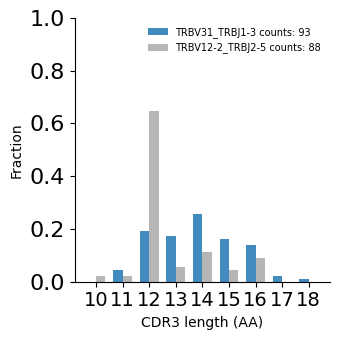

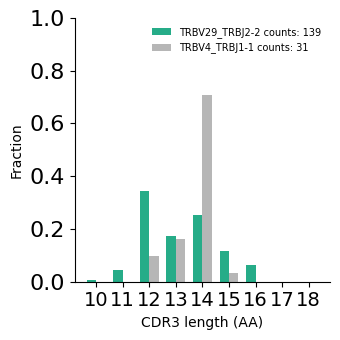

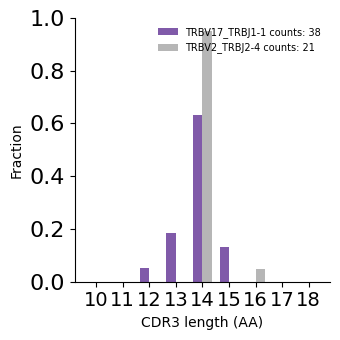

In [67]:
df1=df_tcr.loc[(df_tcr.annotated_specificity=='OVA') & (df_tcr.trb_vj==fr_ova[0])]
df2=df_tcr.loc[(df_tcr.annotated_specificity=='OVA') & (df_tcr.trb_vj==fr_ova[1])]
c1 = len(df1)
c2 = len(df2)
fig = plot_cdr3_spectratype_bars(
    df1 = df1,
    df2 = df2,
    length_col="cdr3a_aa_len",
    label1=f"{fr_ova[0]} counts: {c1}",
    label2=f"{fr_ova[1]} counts: {c2}",
    color1="#1F77B4",
    color2="darkgray",
    bar_width = 0.35
)
fig.savefig('./manuscript_figures/figure4_cdr3len_spectra_enriched_v_non_OVA_quantile_selection.pdf')
df1=df_tcr.loc[(df_tcr.annotated_specificity=='GP33') & (df_tcr.trb_vj==fr_gp33[0])]
df2=df_tcr.loc[(df_tcr.annotated_specificity=='GP33') & (df_tcr.trb_vj==fr_gp33[1])]
c1 = len(df1)
c2 = len(df2)
fig = plot_cdr3_spectratype_bars(
    df1 = df1,
    df2 = df2,    
    length_col="cdr3a_aa_len",
    label1=f"{fr_gp33[0]} counts: {c1}",
    label2=f"{fr_gp33[1]} counts: {c2}",
    color1="#009E73",
    color2="darkgray",
    bar_width = 0.35
)
fig.savefig('./manuscript_figures/figure4_cdr3len_spectra_enriched_v_non_GP33_quantile_selection.pdf')
df1=df_tcr.loc[(df_tcr.annotated_specificity=='M45') & (df_tcr.trb_vj==fr_m45[0])]
df2=df_tcr.loc[(df_tcr.annotated_specificity=='M45') & (df_tcr.trb_vj==fr_m45[1])]
c1 = len(df1)
c2 = len(df2)
fig = plot_cdr3_spectratype_bars(
    df1 = df1,
    df2 = df2,
    length_col="cdr3a_aa_len",
    label1=f"{fr_m45[0]} counts: {c1}",
    label2=f"{fr_m45[1]} counts: {c2}",
    color1="#6A3D9A",
    color2="darkgray",
    bar_width = 0.35
)
fig.savefig('./manuscript_figures/figure4_cdr3len_spectra_enriched_v_non_M45_quantile_selection.pdf')

## Compare Alpha vs Beta enrichment

In [68]:
#threshold for enrichment
enrich_col="tra_vj"
fc_threshold = 2
temp = pd.DataFrame(df_naive_tcr[enrich_col].value_counts()).reset_index()
enrich_vj = temp[temp['count']>2].tra_vj.unique().tolist()

# TRA-VJ enrichment, paired TRB diversity
df_enrich_tra, paired_div_tra, stats_tra = (
    diversity_analysis.run_epitope_analysis_generalized(
        df_tcr=df_tcr.loc[(df_tcr[enrich_col].isin(enrich_vj)) & (df_tcr.pgen_cdr3_a_aa>0)].reset_index(), # run only on vj present in naive,
        df_naive_tcr=df_naive_tcr,
        epitopes=epitopes,

        enrich_col="tra_vj",
        paired_col="trb_vj",
        paired_cdr3_len_col="cdr3b_aa_len",

        specificity_col="annotated_specificity",
        clone_size_col="norm_TCR_expansion",
        pgen_col="pgen_cdr3_ab",

        fc_threshold=2,
        eps=1e-10,
        naive_missing_count=1,

        group_order=(
            "Non-enriched",
            "Enriched",
        ),

        # Holm correction across epitopes,
        # applied independently for each metric
        p_adjust="holm-sidak",
    )
)

# TRB-VJ enrichment, paired TRA diversity
df_enrich_trb, paired_div_trb, stats_trb = (
    diversity_analysis.run_epitope_analysis_generalized(
        df_tcr=df_tcr,
        df_naive_tcr=df_naive_tcr,
        epitopes=epitopes,

        enrich_col="trb_vj",
        paired_col="tra_vj",
        paired_cdr3_len_col="cdr3a_aa_len",

        specificity_col="annotated_specificity",
        clone_size_col="norm_TCR_expansion",
        pgen_col="pgen_cdr3_ab",

        fc_threshold=2,
        eps=1e-10,
        naive_missing_count=1,

        group_order=(
            "Non-enriched",
            "Enriched",
        ),

        # Holm correction across epitopes,
        # applied independently for each metric
        p_adjust="holm-sidak",
    )
)

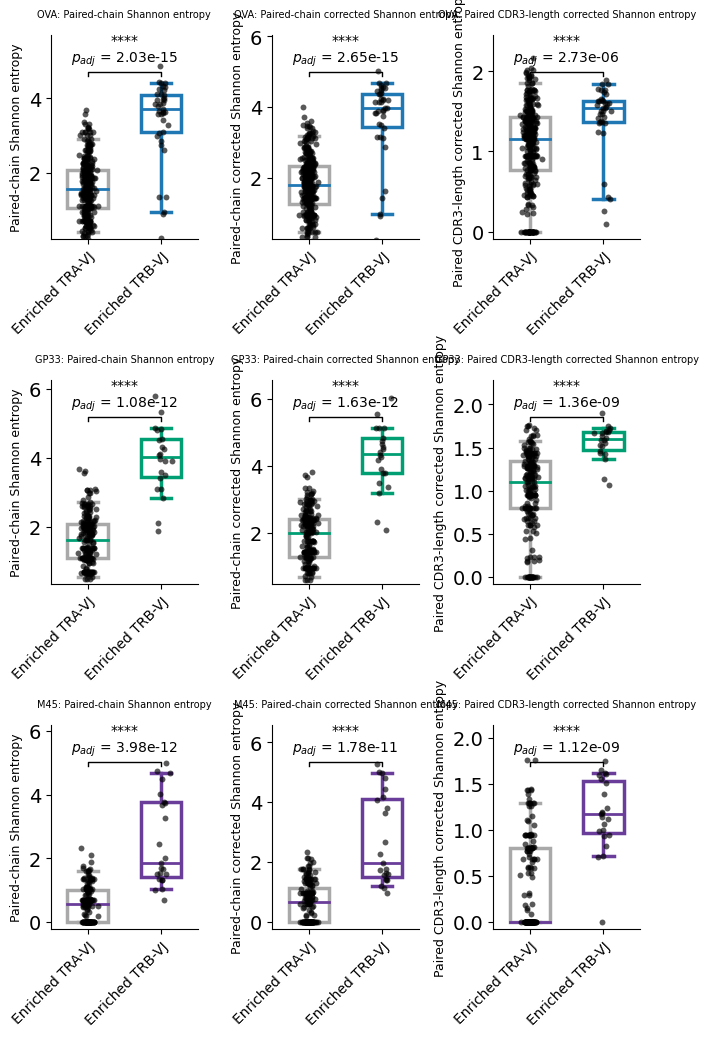

In [69]:
import enriched_tra_trb_comparison as tra_trb_comparison

compare_df = (
    tra_trb_comparison.build_enriched_framework_comparison(
        paired_div_tra=paired_div_tra,
        paired_div_trb=paired_div_trb,
    )
)

metrics = [
    (
        "paired_shannon_entropy",
        "Paired-chain Shannon entropy",
    ),
    (
        "paired_shannon_entropy_corrected",
        "Paired-chain corrected Shannon entropy",
    ),
    (
        "paired_cdr3_len_shannon_entropy_corrected",
        "Paired CDR3-length corrected Shannon entropy",
    ),
]

axis_settings = {
    "paired_shannon_entropy": {
        "yscale": "linear",
        "ylim": None,
        "xlim": (0.5, 2.5),
    },
    "paired_shannon_entropy_corrected": {
        "yscale": "linear",
        "ylim": None,
        "xlim": (0.5, 2.5),
    },
    "paired_cdr3_len_shannon_entropy_corrected": {
        "yscale": "linear",
        "ylim": None,
        "xlim": (0.5, 2.5),
    },
}

comparison_results = (
    tra_trb_comparison.plot_enriched_tra_trb_comparison(
        compare_df=compare_df,
        epitopes=epitopes,
        metrics=metrics,
        axis_settings=axis_settings,
        epitope_colors=epitope_colors,

        epitope_col="epitope",
        group_col="enriched_framework_type",
        group_order=(
            "Enriched TRA-VJ",
            "Enriched TRB-VJ",
        ),

        # First box is gray; second box uses the epitope color
        first_group_color="darkgray",

        # Mann–Whitney U within each epitope;
        # correction across epitopes separately for each metric
        p_adjust="holm-sidak",

        # Approximate subplot dimensions in inches
        box_width=2.2,
        subplot_height=3.5,

        # Boxplot formatting
        whis=(5, 95),
        boxplot_width=0.55,
        box_linewidth=2.5,

        # None means both medians use the epitope color
        median_color=None,
        median_linewidth=2.0,

        # Every observation is plotted
        point_color="black",
        point_size=18,
        point_alpha=0.65,
        point_jitter=0.045,

        # Statistical annotation
        stat_label="both",       # "stars", "p", or "both"
        stat_bracket_y=0.80,
        stat_text_y=0.84,
        stat_linewidth=1.0,

        # Titles and labels
        title_y=1.06,
        title_fontsize=7,
        ylabel_fontsize=9,
        xtick_rotation=45,

        random_state=1,

        save_pdf=True,
        pdf_path= "./manuscript_figures/figure4_summary_tcr_enrichment_alpha_vs_beta.pdf",
        show=True,
    )
)

-

-

-

-

# Figure 5

## Framework total numbers

### IMGT genes

TRAV

In [70]:
imgt = pd.read_csv('./10X_mouse_vdj/IMGT_reference/trav_amino_acid.csv')
imgt = imgt[imgt["trav"].str.endswith("*01")]
imgt["trav"] = imgt["trav"].str.replace("*01", "", regex=False)
imgt = imgt[imgt["functional"]=='F'].reset_index(drop=True).copy()
print('trav genes: ' + str(imgt.trav.nunique()))

total_trav = imgt.trav.nunique()
print(total_trav)

imgt.to_excel('./10X_mouse_vdj/imgt_trav_functional.xlsx')

trav genes: 109
109


TRBV

In [71]:
imgt = pd.read_csv('./10X_mouse_vdj/IMGT_reference/trbv_amino_acid.csv')
imgt = imgt[imgt["trbv"].str.endswith("*01")]
imgt["trbv"] = imgt["trbv"].str.replace("*01", "", regex=False)
imgt = imgt[imgt["trbv"]!='TRBV24'] #non functional in Bl/6: pseudogene
imgt = imgt[imgt["functional"]=='F'].reset_index(drop=True).copy()

imgt.loc[len(imgt)] = {"trbv": "TRBV12-2+TRBV13-2"}
total_trbv = imgt.trbv.nunique()
print('trbv genes: ' + str(imgt.trbv.nunique()))

imgt_trbv = imgt["trbv"].unique().tolist()
data_trbv = df_tcr.vb.unique().tolist()
missing = [vb for vb in imgt_trbv if vb not in data_trbv]
print(missing)

imgt.to_excel('./10X_mouse_vdj/imgt_trbv_functional.xlsx')

trbv genes: 22
[]


TRAJ

In [72]:
imgt = pd.read_csv('./10X_mouse_vdj/IMGT_reference/traj_amino_acid.csv')
imgt = imgt[imgt["traj"].str.endswith("*01")]
imgt["traj"] = imgt["traj"].str.replace("*01", "", regex=False)
#imgt = imgt[imgt["functional"]=='F'].reset_index(drop=True).copy()
print('traj genes: ' + str(imgt.traj.nunique()))

### Correct TRAJ genes
j_list = imgt[imgt.functional!='F'].traj.tolist()
data_j = df_tcr.ja.unique().tolist()
funct = [ja for ja in j_list if ja in data_j]

imgt.loc[imgt['traj'].isin(funct), 'functional'] = 'F'
imgt.loc[imgt['traj'].isin(funct), 'mouse_origin'] = 'C57Bl/6'
imgt = imgt[imgt["functional"]=='F'].reset_index(drop=True).copy()
print('traj genes: ' + str(imgt.traj.nunique()))
total_traj = imgt.traj.nunique()
imgt.to_excel('./10X_mouse_vdj/imgt_traj_functional.xlsx')

traj genes: 55
traj genes: 43


TRBJ

In [73]:
imgt = pd.read_csv('./10X_mouse_vdj/IMGT_reference/trbj_amino_acid.csv')
imgt = imgt[imgt["trbj"].str.endswith("*01")]
imgt["trbj"] = imgt["trbj"].str.replace("*01", "", regex=False)
#imgt = imgt[imgt["functional"]=='F'].reset_index(drop=True).copy()
print('trbj genes: ' + str(imgt.trbj.nunique()))

### Correct TRAJ genes
j_list = imgt[imgt.functional!='F'].trbj.tolist()
data_j = df_tcr.jb.unique().tolist()
funct = [jb for jb in j_list if jb in data_j]

imgt.loc[imgt['trbj'].isin(funct), 'functional'] = 'F'
imgt.loc[imgt['trbj'].isin(funct), 'mouse_origin'] = 'C57Bl/6'
imgt = imgt[imgt["functional"]=='F'].reset_index(drop=True).copy()
print('trbj genes: ' + str(imgt.trbj.nunique()))
total_trbj = imgt.trbj.nunique()
imgt.to_excel('./10X_mouse_vdj/imgt_trbj_functional.xlsx')

trbj genes: 14
trbj genes: 12


### Plot gene counts per repertoire

In [74]:
df_genes = pd.DataFrame(df_tcr.groupby("annotated_specificity").agg(
    vb=("vb", "nunique"),
    va=("va", "nunique"),
    ja=("ja", "nunique"),
    jb=("jb", "nunique")
))



/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/779862785.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/779862785.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/779862785.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/779862785.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[i].set_xticklabels(ax[i].get_xtick

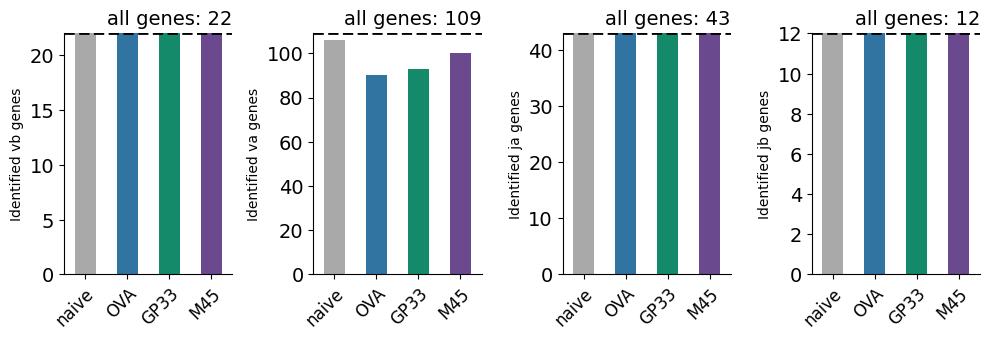

In [75]:
df_plot = df_genes[df_genes.index!='M38'].reset_index()

epitope_list = ['naive', 'OVA','GP33','M45']
color_list = ['darkgray', '#1F77B4','#009E73','#6A3D9A']
y_values = ['vb','va','ja','jb']
total_genes = [total_trbv,total_trav,total_traj,total_trbj,]
colors = color_list

fig, ax = plt.subplots(ncols = 4, figsize = (10,3.5))

for i, yval in enumerate(y_values):

    sns.barplot(df_plot, x = 'annotated_specificity', y = yval, ax=ax[i], palette=colors, legend=False, hue = 'annotated_specificity',
                order = epitope_list, hue_order = epitope_list, width = 0.5)
        
    ax[i].set_xlabel('')
    ax[i].set_ylim(0,total_genes[i])
    ax[i].set_ylabel('Identified ' + yval + ' genes')
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')
    ax[i].tick_params(axis='y', labelsize = 14)

    y_ref = total_genes[i] 
    ax[i].axhline(y=y_ref, linestyle="--", color="black", linewidth=2)

    # numeric label near the right edge
    ax[i].text(
        3.5,   # x-position (adjust if needed)
        y_ref * 1.02 ,           # y-position
        'all genes: ' + f"{y_ref}",
        va="bottom",
        ha="right",
        color="black",
        fontsize=14
    )

fig.tight_layout()
fig.savefig("./manuscript_figures/figure5_all_detected_genes.pdf")

VJ - VDJ recombination

In [76]:
n_total_genes = total_trbv*total_trav*total_traj*total_trbj
n_total_tra = total_trav*total_traj
n_total_trb = total_trbv*total_trbj

In [77]:
n_total_genes

1237368

In [78]:
df_tcr['gene_recombination'] = df_tcr['va'] + '_' + df_tcr['ja'] + '__' + df_tcr['vb'] + '_' + df_tcr['jb']

In [79]:
df_tcr['tcr_vj'] = df_tcr['va'] + '_' + df_tcr['ja'] + '__' + df_tcr['vb'] + '_' + df_tcr['jb']
df_tcr['trb_vj'] = df_tcr['vb'] + '_' + df_tcr['jb']
df_tcr['tra_vj'] = df_tcr['va'] + '_' + df_tcr['ja']

In [80]:
df_genes = pd.DataFrame(df_tcr.groupby("annotated_specificity").agg(
    tcr_vj=("tcr_vj", "nunique"),
    trb_vj=("trb_vj", "nunique"),
    tra_vj=("tra_vj", "nunique"),
)).reset_index()
df_genes['freq_tcr'] = df_genes['tcr_vj']/n_total_genes*100
df_genes['freq_trb'] = df_genes['trb_vj']/n_total_trb*100
df_genes['freq_tra'] = df_genes['tra_vj']/n_total_tra*100
df_genes['total_tcr'] = n_total_genes
df_genes['total_trb'] = n_total_trb
df_genes['total_tra'] = n_total_tra

In [81]:
df_genes

,annotated_specificity,tcr_vj,trb_vj,tra_vj,freq_tcr,freq_trb,freq_tra,total_tcr,total_trb,total_tra
0,GP33,5079,226,1497,0.410468,85.606061,31.939407,1237368,264,4687
1,M45,1837,164,1070,0.148460,62.121212,22.829102,1237368,264,4687
2,OVA,8116,251,2092,0.655908,95.075758,44.634094,1237368,264,4687
3,naive,68353,263,3884,5.524064,99.621212,82.867506,1237368,264,4687


/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/614150041.py:24: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/614150041.py:24: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/614150041.py:24: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')


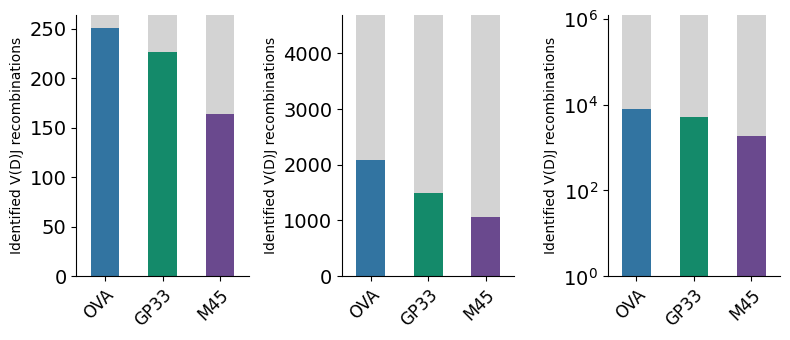

In [82]:
epitope_list = ['OVA','GP33','M45']
color_list = ['#1F77B4','#009E73','#6A3D9A']

fig, ax = plt.subplots(ncols=3, figsize = (8,3.5))

plot_list = ['trb_vj','tra_vj','tcr_vj']
count_list = ['total_trb','total_tra','total_tcr']
lim_list = [(0,n_total_trb),(0,n_total_tra),(1,n_total_genes)]
scale_list = ['linear','linear','log']

for i, v_j in enumerate(plot_list):
    sns.barplot(df_genes, x = 'annotated_specificity', y = count_list[i], ax=ax[i], palette=['lightgray','lightgray','lightgray'], legend=False,
                    hue = 'annotated_specificity', order = epitope_list, hue_order = epitope_list, width = 0.5)
    sns.barplot(df_genes, x = 'annotated_specificity', y = v_j, ax=ax[i], palette=color_list, legend=False, hue = 'annotated_specificity',
                    order = epitope_list, hue_order = epitope_list, width = 0.5)
        
    ax[i].set_xlabel('')
    ax[i].set_ylabel('Identified V(D)J recombinations')
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_ylim(lim_list[i])
    ax[i].set_yscale(scale_list[i])
        
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')
    ax[i].tick_params(axis='y', labelsize = 14)

fig.tight_layout()
#ax.axhline(y=n_total_genes, linestyle="--", color="black", linewidth=2)
#ax.text(
#        3.5,   # x-position (adjust if needed)
#        n_total_genes * 1.5 ,           # y-position
#        'all genes: ' + f"{n_total_genes}",
#        va="bottom",
#        ha="right",
#        color="black",
#        fontsize=14
#    )
#fig.tight_layout()
fig.savefig("./manuscript_figures/figure5_all_detected_vdj_recomb_count.pdf")

/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/2599980319.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')


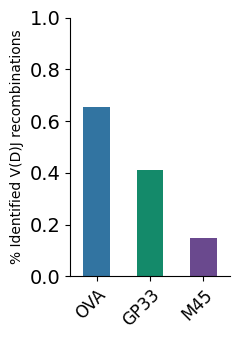

In [83]:
epitope_list = ['OVA','GP33','M45']
color_list = ['#1F77B4','#009E73','#6A3D9A']

fig, ax = plt.subplots(figsize = (2.5,3.5))

sns.barplot(df_genes, x = 'annotated_specificity', y = 'freq_tcr', ax=ax, palette=color_list, legend=False, hue = 'annotated_specificity',
                order = epitope_list, hue_order = epitope_list, width = 0.5)
        
ax.set_xlabel('')
ax.set_ylim(0,1)
ax.set_ylabel('% Identified V(D)J recombinations')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
    
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')
ax.tick_params(axis='y', labelsize = 14)

fig.tight_layout()
fig.savefig("./manuscript_figures/figure5_all_detected_vdj_recomb_freq.pdf")

## Clone sizes by gene usage

In [84]:
df_pivot = df_tcr.pivot_table(
    index="vb",
    columns="annotated_specificity",
    values="norm_TCR_expansion",
    aggfunc="max"
).reset_index()
#df_size

/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/4064127120.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data = df_plot, x='annotated_specificity', y = 'max_size', hue = 'annotated_specificity',
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/4064127120.py:26: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')


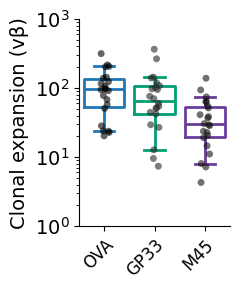

In [85]:
epitope_list = ['OVA','GP33','M45']
color_list = ['#1F77B4','#009E73','#6A3D9A']

colors = color_list

epitope_colors = {'OVA': '#1F77B4', 'GP33': '#009E73', 'M45': '#6A3D9A'}

#df_plot
df_plot = pd.DataFrame(df_tcr[df_tcr.annotated_specificity.isin(epitope_list)].groupby(['annotated_specificity', 'vb']).agg(
    max_size=("norm_TCR_expansion", "max")).reset_index())


fig, ax = plt.subplots(figsize = (2.5,3))

sns.boxplot(data = df_plot, x='annotated_specificity', y = 'max_size', hue = 'annotated_specificity',
            showfliers=False, whis = (5,95), order = epitope_list, linewidth = 2, ax=ax,
           palette = epitope_colors, fill = False)
sns.stripplot(data = df_plot, x='annotated_specificity', y = 'max_size', hue = 'annotated_specificity',
              size = 5, color ='black', alpha = 0.6, ax=ax)

ax.set_xlabel('')
ax.set_ylabel('Clonal expansion (vβ)', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')
ax.tick_params(axis='y', labelsize = 14)

ax.set_yscale('log')
ax.set_ylim(1, 1000)

fig.tight_layout()

fig.savefig("./manuscript_figures/figure5_clone_size_by_vb.pdf")

In [86]:
threshold = 5

percent_exceeding = (
    df_plot["max_size"]
    .ge(threshold)
    .groupby(df_plot["annotated_specificity"])
    .mean()
    .mul(100)
    .reset_index(name="percent_above_threshold")
)
percent_exceeding

,annotated_specificity,percent_above_threshold
0,GP33,100.000000
1,M45,95.454545
2,OVA,100.000000


In [87]:
df_tcr['trb_vj'] = df_tcr['vb'] + '_' + df_tcr['jb']
df_tcr['tra_vj'] = df_tcr['va'] + '_' + df_tcr['ja']

/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/492157539.py:15: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data = df_plot, x='annotated_specificity', y = 'max_size', hue = 'annotated_specificity',
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/492157539.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')


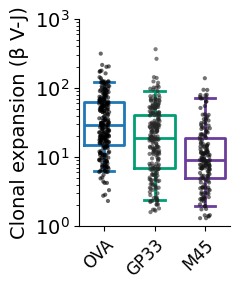

In [88]:
epitope_list = ['OVA','GP33','M45']
color_list = ['#1F77B4','#009E73','#6A3D9A']

colors = color_list

#df_plot
df_plot = pd.DataFrame(df_tcr[df_tcr.annotated_specificity.isin(epitope_list)].groupby(['annotated_specificity', 'trb_vj']).agg(
    max_size=("norm_TCR_expansion", "max")).reset_index())


fig, ax = plt.subplots(figsize = (2.5,3))
sns.boxplot(data = df_plot, x='annotated_specificity', y = 'max_size', hue = 'annotated_specificity',
            showfliers=False, whis = (5,95), order = epitope_list, linewidth = 2, ax=ax,
           palette = epitope_colors, fill = False)
sns.stripplot(data = df_plot, x='annotated_specificity', y = 'max_size', hue = 'annotated_specificity',
              size = 3, color ='black', alpha = 0.6, ax=ax)

ax.set_xlabel('')
ax.set_ylabel('Clonal expansion (β V-J)', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')
ax.tick_params(axis='y', labelsize = 14)

ax.set_yscale('log')
ax.set_ylim(1, 1000)

fig.tight_layout()

fig.savefig("./manuscript_figures/figure5_clone_size_by_trb_vj.pdf")

In [89]:
threshold = 5

percent_exceeding = (
    df_plot["max_size"]
    .ge(threshold)
    .groupby(df_plot["annotated_specificity"])
    .mean()
    .mul(100)
    .reset_index(name="percent_above_threshold")
)
percent_exceeding

,annotated_specificity,percent_above_threshold
0,GP33,82.743363
1,M45,75.000000
2,OVA,96.812749


/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/2422231128.py:15: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data = df_plot, x='annotated_specificity', y = 'max_size', hue = 'annotated_specificity',
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/2422231128.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')


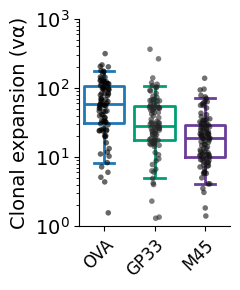

In [90]:
epitope_list = ['OVA','GP33','M45']
color_list = ['#1F77B4','#009E73','#6A3D9A']

colors = color_list

#df_plot
df_plot = pd.DataFrame(df_tcr[df_tcr.annotated_specificity.isin(epitope_list)].groupby(['annotated_specificity', 'va']).agg(
    max_size=("norm_TCR_expansion", "max")).reset_index())


fig, ax = plt.subplots(figsize = (2.5,3))
sns.boxplot(data = df_plot, x='annotated_specificity', y = 'max_size', hue = 'annotated_specificity',
            showfliers=False, whis = (5,95), order = epitope_list, linewidth = 2, ax=ax,
           palette = epitope_colors, fill = False)
sns.stripplot(data = df_plot, x='annotated_specificity', y = 'max_size', hue = 'annotated_specificity',
              size = 4, color ='black', alpha = 0.6, ax=ax)

ax.set_xlabel('')
ax.set_ylabel('Clonal expansion (vα)', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')
ax.tick_params(axis='y', labelsize = 14)

ax.set_yscale('log')
ax.set_ylim(1, 1000)

fig.tight_layout()

#fig.savefig("./figure_drafts/tcr_counts_predicted.pdf", format="pdf", bbox_inches="tight")
fig.savefig("./manuscript_figures/figure5_clone_size_by_va.pdf")

In [91]:
threshold = 5

percent_exceeding = (
    df_plot["max_size"]
    .ge(threshold)
    .groupby(df_plot["annotated_specificity"])
    .mean()
    .mul(100)
    .reset_index(name="percent_above_threshold")
)
percent_exceeding

,annotated_specificity,percent_above_threshold
0,GP33,93.548387
1,M45,94.000000
2,OVA,97.777778


/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/394195040.py:15: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data = df_plot, x='annotated_specificity', y = 'max_size', hue = 'annotated_specificity',
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/394195040.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')


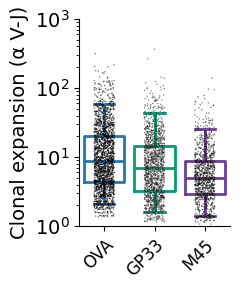

In [92]:
epitope_list = ['OVA','GP33','M45']
color_list = ['#1F77B4','#009E73','#6A3D9A']

colors = color_list

#df_plot
df_plot = pd.DataFrame(df_tcr[df_tcr.annotated_specificity.isin(epitope_list)].groupby(['annotated_specificity', 'tra_vj']).agg(
    max_size=("norm_TCR_expansion", "max")).reset_index())


fig, ax = plt.subplots(figsize = (2.5,3))
sns.boxplot(data = df_plot, x='annotated_specificity', y = 'max_size', hue = 'annotated_specificity',
            showfliers=False, whis = (5,95), order = epitope_list, linewidth = 2, ax=ax,
           palette = epitope_colors, fill = False)
sns.stripplot(data = df_plot, x='annotated_specificity', y = 'max_size', hue = 'annotated_specificity',
              size = 1, color ='black', alpha = 0.6, ax=ax, jitter = 0.2)

ax.set_xlabel('')
ax.set_ylabel('Clonal expansion (α V-J)', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')
ax.tick_params(axis='y', labelsize = 14)

ax.set_yscale('log')
ax.set_ylim(1, 1000)

fig.tight_layout()

fig.savefig("./manuscript_figures/figure5_clone_size_by_tra_vj.pdf")

In [93]:
threshold = 5

percent_exceeding = (
    df_plot["max_size"]
    .ge(threshold)
    .groupby(df_plot["annotated_specificity"])
    .mean()
    .mul(100)
    .reset_index(name="percent_above_threshold")
)
percent_exceeding

,annotated_specificity,percent_above_threshold
0,GP33,59.986640
1,M45,50.373832
2,OVA,68.785851


## Germline sharedness

In [94]:
df_tcr['tcr_vj'] = df_tcr['tra_vj'] + '__' + df_tcr['trb_vj']
#false annotation in data
sel_tcr_vj = 'TRAV12-2_TRAJ34__TRBV29_TRBJ2-1'
df_tcr.loc[(df_tcr.tcr_vj==sel_tcr_vj) & (df_tcr.annotated_specificity=='GP33'), "annotated_specificity"] = 'below_threshold'

In [95]:
import pandas as pd


def calculate_sharedness(
    df: pd.DataFrame,
    groups_to_use,
    group_col: str = "g1",
    analysis_col: str = "ac1",
    contributor_col: str = "c1",
):
    groups_to_use = list(dict.fromkeys(groups_to_use))

    if not groups_to_use:
        raise ValueError(
            "groups_to_use must contain at least one group."
        )

    required_columns = {
        group_col,
        analysis_col,
        contributor_col,
    }

    missing_columns = sorted(
        required_columns.difference(df.columns)
    )

    if missing_columns:
        raise KeyError(
            f"Missing required columns: {missing_columns}"
        )


# Restrict analysis to explicitly selected groups


    data = (
        df.loc[
            df[group_col].isin(groups_to_use),
            [
                group_col,
                analysis_col,
                contributor_col,
            ],
        ]
        .dropna(
            subset=[
                group_col,
                analysis_col,
            ]
        )
        .copy()
    )

    if data.empty:
        raise ValueError(
            "No rows remain after filtering to groups_to_use."
        )

    # Preserve the requested group order in outputs.
    data[group_col] = pd.Categorical(
        data[group_col],
        categories=groups_to_use,
        ordered=True,
    )


# Identify groups


    ac1_group_presence = (
        data[
            [
                analysis_col,
                group_col,
            ]
        ]
        .drop_duplicates()
    )

    def ordered_groups_present(values):
        observed_groups = set(values.dropna())

        return tuple(
            group
            for group in groups_to_use
            if group in observed_groups
        )

    ac1_detail = (
        ac1_group_presence
        .groupby(
            analysis_col,
            observed=True,
            sort=False,
        )
        .agg(
            sharedness=(
                group_col,
                "nunique",
            ),
            groups_present=(
                group_col,
                ordered_groups_present,
            ),
        )
        .reset_index()
    )

    # Ensure sharedness is an integer, not categorical.
    ac1_detail["sharedness"] = (
        ac1_detail["sharedness"]
        .astype(int)
    )

    ac1_detail = (
        ac1_detail
        .sort_values(
            [
                "sharedness",
                analysis_col,
            ]
        )
        .reset_index(drop=True)
    )


# Count observed values at each exact sharedness value


    sharedness_summary = (
        ac1_detail
        .groupby(
            "sharedness",
            observed=True,
        )
        .agg(
            n_unique_ac1=(
                analysis_col,
                "nunique",
            )
        )
        .reset_index()
        .sort_values("sharedness")
        .reset_index(drop=True)
    )

    # Optionally include absent sharedness levels as zeros.
    all_sharedness_levels = pd.DataFrame(
        {
            "sharedness": range(
                1,
                len(groups_to_use) + 1,
            )
        }
    )

    sharedness_summary = (
        all_sharedness_levels
        .merge(
            sharedness_summary,
            on="sharedness",
            how="left",
        )
        .fillna(
            {
                "n_unique_ac1": 0,
            }
        )
    )

    sharedness_summary["n_unique_ac1"] = (
        sharedness_summary["n_unique_ac1"]
        .astype(int)
    )


# Add sharedness to each retained input row


    data_annotated = data.merge(
        ac1_detail[
            [
                analysis_col,
                "sharedness",
                "groups_present",
            ]
        ],
        on=analysis_col,
        how="left",
        validate="many_to_one",
    )

    data_annotated["sharedness"] = (
        data_annotated["sharedness"]
        .astype(int)
    )


# Contribution for each observation × group


    contribution_by_ac1_group = (
        data_annotated
        .groupby(
            [
                analysis_col,
                "sharedness",
                group_col,
            ],
            observed=True,
        )
        .agg(
            n_unique_c1=(
                contributor_col,
                "nunique",
            ),
            n_rows=(
                contributor_col,
                "size",
            ),
        )
        .reset_index()
        .sort_values(
            [
                "sharedness",
                analysis_col,
                group_col,
            ]
        )
        .reset_index(drop=True)
    )


# Overall contribution by group and sharedness


    contribution_by_group = (
        data_annotated
        .groupby(
            [
                group_col,
                "sharedness",
            ],
            observed=True,
        )
        .agg(
            n_unique_ac1=(
                analysis_col,
                "nunique",
            ),
            n_unique_c1=(
                contributor_col,
                "nunique",
            ),
            n_rows=(
                contributor_col,
                "size",
            ),
        )
        .reset_index()
        .sort_values(
            [
                group_col,
                "sharedness",
            ]
        )
        .reset_index(drop=True)
    )

    return {
        "filtered_data": data_annotated,
        "ac1_detail": ac1_detail,
        "sharedness_summary": sharedness_summary,
        "contribution_by_group": contribution_by_group,
        "contribution_by_ac1_group": contribution_by_ac1_group,
    }

In [96]:
groups_to_use = [
    "OVA",
    "naive",
]

results = calculate_sharedness(
    df=df_tcr[df_tcr.annotated_specificity.isin(groups_to_use)].reset_index(drop=True),
    groups_to_use=groups_to_use,
    group_col="annotated_specificity",
    analysis_col="tcr_vj",
    contributor_col="tcr_id",
)

ep_unique = df_tcr[df_tcr.annotated_specificity=='OVA'].tcr_vj.nunique()
results['sharedness_summary'].loc[results['sharedness_summary'].sharedness==1,'n_unique_ac1'] = ep_unique
results['sharedness_summary'].rename(columns = {'n_unique_ac1':'ova_naive'}, inplace=True)
df = results['sharedness_summary'].copy()


In [97]:
groups_to_use = [
    "GP33",
    "naive",
]

results = calculate_sharedness(
    df=df_tcr[df_tcr.annotated_specificity.isin(groups_to_use)].reset_index(drop=True),
    groups_to_use=groups_to_use,
    group_col="annotated_specificity",
    analysis_col="tcr_vj",
    contributor_col="tcr_id",
)

ep_unique = df_tcr[df_tcr.annotated_specificity=='GP33'].tcr_vj.nunique()
results['sharedness_summary'].loc[results['sharedness_summary'].sharedness==1,'n_unique_ac1'] = ep_unique
results['sharedness_summary'].rename(columns = {'n_unique_ac1':'gp33_naive'}, inplace=True)

df['gp33_naive'] = results['sharedness_summary']['gp33_naive'].copy()

groups_to_use = [
    "M45",
    "naive",
]

results = calculate_sharedness(
    df=df_tcr[df_tcr.annotated_specificity.isin(groups_to_use)].reset_index(drop=True),
    groups_to_use=groups_to_use,
    group_col="annotated_specificity",
    analysis_col="tcr_vj",
    contributor_col="tcr_id",
)

ep_unique = df_tcr[df_tcr.annotated_specificity=='M45'].tcr_vj.nunique()
results['sharedness_summary'].loc[results['sharedness_summary'].sharedness==1,'n_unique_ac1'] = ep_unique
results['sharedness_summary'].rename(columns = {'n_unique_ac1':'m45_naive'}, inplace=True)

df['m45_naive'] = results['sharedness_summary']['m45_naive'].copy()

groups_to_use = [
    "OVA",
    "GP33",
]

results = calculate_sharedness(
    df=df_tcr[df_tcr.annotated_specificity.isin(groups_to_use)].reset_index(drop=True),
    groups_to_use=groups_to_use,
    group_col="annotated_specificity",
    analysis_col="tcr_vj",
    contributor_col="tcr_id",
)

ep_unique = df_tcr[df_tcr.annotated_specificity=='OVA'].tcr_vj.nunique()
results['sharedness_summary'].loc[results['sharedness_summary'].sharedness==1,'n_unique_ac1'] = ep_unique
results['sharedness_summary'].rename(columns = {'n_unique_ac1':'ova_gp33'}, inplace=True)

df['ova_gp33'] = results['sharedness_summary']['ova_gp33'].copy()

groups_to_use = [
    "OVA",
    "M45",
]

results = calculate_sharedness(
    df=df_tcr[df_tcr.annotated_specificity.isin(groups_to_use)].reset_index(drop=True),
    groups_to_use=groups_to_use,
    group_col="annotated_specificity",
    analysis_col="tcr_vj",
    contributor_col="tcr_id",
)

ep_unique = df_tcr[df_tcr.annotated_specificity=='OVA'].tcr_vj.nunique()
results['sharedness_summary'].loc[results['sharedness_summary'].sharedness==1,'n_unique_ac1'] = ep_unique
results['sharedness_summary'].rename(columns = {'n_unique_ac1':'ova_m45'}, inplace=True)

df['ova_m45'] = results['sharedness_summary']['ova_m45'].copy()

groups_to_use = [
    "GP33",
    "M45",
]

results = calculate_sharedness(
    df=df_tcr[df_tcr.annotated_specificity.isin(groups_to_use)].reset_index(drop=True),
    groups_to_use=groups_to_use,
    group_col="annotated_specificity",
    analysis_col="tcr_vj",
    contributor_col="tcr_id",
)

ep_unique = df_tcr[df_tcr.annotated_specificity=='GP33'].tcr_vj.nunique()
results['sharedness_summary'].loc[results['sharedness_summary'].sharedness==1,'n_unique_ac1'] = ep_unique
results['sharedness_summary'].rename(columns = {'n_unique_ac1':'gp33_m45'}, inplace=True)

df['gp33_m45'] = results['sharedness_summary']['gp33_m45'].copy()
df = pd.DataFrame(df)
df

,sharedness,ova_naive,gp33_naive,m45_naive,ova_gp33,ova_m45,gp33_m45
0,1,8116,5078,1837,8116,8116,5078
1,2,1624,1160,301,153,32,42


In [98]:
groups_to_use = [
    "OVA",
    "GP33",
    "M45",
]

results = calculate_sharedness(
    df=df_tcr[df_tcr.annotated_specificity.isin(groups_to_use)].reset_index(drop=True),
    groups_to_use=groups_to_use,
    group_col="annotated_specificity",
    analysis_col="tcr_vj",
    contributor_col="tcr_id",
)
results['sharedness_summary']

,sharedness,n_unique_ac1
0,1,14577
1,2,227
2,3,0


In [99]:
results["ac1_detail"].sort_values(by='sharedness', ascending=False)

,tcr_vj,sharedness,groups_present
14803,TRAV9D-3_TRAJ6__TRBV17_TRBJ1-6,2,"(OVA, GP33)"
14661,TRAV16D-DV11_TRAJ23__TRBV29_TRBJ1-2,2,"(OVA, GP33)"
14659,TRAV14N-3_TRAJ50__TRBV29_TRBJ1-1,2,"(OVA, GP33)"
14658,TRAV14N-3_TRAJ22__TRBV29_TRBJ2-7,2,"(OVA, GP33)"
14657,TRAV14N-3_TRAJ11__TRBV19_TRBJ2-7,2,"(OVA, GP33)"
...,...,...,...
4937,TRAV14D-3-DV8_TRAJ21__TRBV13-3_TRBJ2-4,1,"(OVA,)"
4938,TRAV14D-3-DV8_TRAJ21__TRBV14_TRBJ1-5,1,"(OVA,)"
4939,TRAV14D-3-DV8_TRAJ21__TRBV19_TRBJ2-4,1,"(OVA,)"
4940,TRAV14D-3-DV8_TRAJ21__TRBV29_TRBJ1-3,1,"(OVA,)"


In [100]:
df = results["ac1_detail"].copy()

groups_required = [{"OVA", "GP33"}, {"OVA", "M45"}, {"GP33", "M45"}]
vj_list = []

for group in groups_required:
    filtered = df.loc[
        df["groups_present"].apply(
            lambda groups: group.issubset(groups)
        )
    ].copy()
    vj_list.append(filtered.tcr_vj.tolist())

/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/4024879057.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data = df_plot, x='annotated_specificity', y = 'norm_TCR_expansion', hue = 'annotated_specificity',
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/4024879057.py:22: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data = df_plot, x='annotated_specificity', y = 'norm_TCR_expansion', hue = 'annotated_specificity',
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_52427/4024879057.py:32: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data = df_plot, x='annotated_specificity', y = 

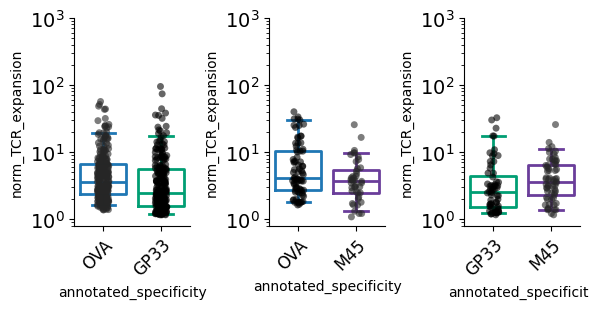

In [101]:
epitope_colors = {'OVA': '#1F77B4', 'GP33': '#009E73', 'M45': '#6A3D9A'}

group = ['OVA', 'GP33']
df_plot = df_tcr[df_tcr.tcr_vj.isin(vj_list[0])].reset_index(drop=True).copy()
df_plot = df_plot[df_plot.annotated_specificity.isin(group)].reset_index(drop=True).copy()

fig, ax = plt.subplots(ncols = 3, figsize = (6, 3.2))

sns.boxplot(data = df_plot, x='annotated_specificity', y = 'norm_TCR_expansion', hue = 'annotated_specificity',
            showfliers=False, whis = (5,95), order = group, linewidth = 2, ax=ax[0],
           palette = epitope_colors, fill = False)
sns.stripplot(data = df_plot, x='annotated_specificity', y = 'norm_TCR_expansion', hue = 'annotated_specificity',
              size = 5, color ='black', alpha = 0.6, ax=ax[0])

group = ['OVA', 'M45']
df_plot = df_tcr[df_tcr.tcr_vj.isin(vj_list[1])].reset_index(drop=True).copy()
df_plot = df_plot[df_plot.annotated_specificity.isin(group)].reset_index(drop=True).copy()

sns.boxplot(data = df_plot, x='annotated_specificity', y = 'norm_TCR_expansion', hue = 'annotated_specificity',
            showfliers=False, whis = (5,95), order = group, linewidth = 2, ax=ax[1],
           palette = epitope_colors, fill = False)
sns.stripplot(data = df_plot, x='annotated_specificity', y = 'norm_TCR_expansion', hue = 'annotated_specificity',
              size = 5, color ='black', alpha = 0.6, ax=ax[1])

group = ['GP33', 'M45']
df_plot = df_tcr[df_tcr.tcr_vj.isin(vj_list[2])].reset_index(drop=True).copy()
df_plot = df_plot[df_plot.annotated_specificity.isin(group)].reset_index(drop=True).copy()

sns.boxplot(data = df_plot, x='annotated_specificity', y = 'norm_TCR_expansion', hue = 'annotated_specificity',
            showfliers=False, whis = (5,95), order = group, linewidth = 2, ax=ax[2],
           palette = epitope_colors, fill = False)
sns.stripplot(data = df_plot, x='annotated_specificity', y = 'norm_TCR_expansion', hue = 'annotated_specificity',
              size = 5, color ='black', alpha = 0.6, ax=ax[2])

for i in range(3):
    ax[i].set_ylim(0.8, 1000)
    ax[i].set_yscale('log')
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right', fontsize=12, rotation_mode='anchor')
    ax[i].tick_params(axis='y', labelsize = 14)

fig.tight_layout()
fig.savefig('./manuscript_figures/figure5_shared_tcr_vj_expansion_per_epitope.pdf')

Number of pairs: 153
Wilcoxon statistic: 4.96e+03
p-value: 0.0908
Number of pairs: 32
Wilcoxon statistic: 210
p-value: 0.322
Number of pairs: 42
Wilcoxon statistic: 399
p-value: 0.519
[0.24837936 0.53992885 0.53992885]


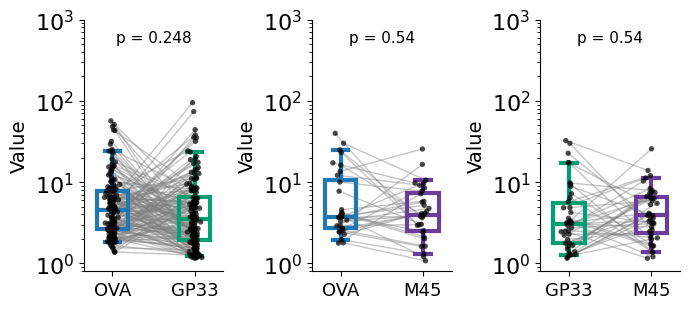

In [102]:
fig, ax = plt.subplots(ncols = 3, figsize=(7, 3.2))
from scipy.stats import wilcoxon

epitope_colors = {'OVA': '#1F77B4', 'GP33': '#009E73', 'M45': '#6A3D9A'}
group_list = [['OVA', 'GP33'],['OVA', 'M45'],['GP33', 'M45']]
#for multitest
raw_p_values = []

for i, group in enumerate(group_list):

    df_plot = df_tcr[df_tcr.tcr_vj.isin(vj_list[i])].reset_index(drop=True).copy()
    df_plot = df_plot[df_plot.annotated_specificity.isin(group)].reset_index(drop=True).copy()
    
    df_plot = pd.DataFrame(df_plot.groupby(['tcr_vj','annotated_specificity']).agg(
        tcr_expansion = ('norm_TCR_expansion','max'),))
    
    df_plot = df_plot.pivot_table(
        index="tcr_vj",
        columns="annotated_specificity",
        values="tcr_expansion",
        aggfunc="max",   # change to "sum", "max", "first", etc.
    )
    df_plot = df_plot.reset_index()

    rng = np.random.default_rng(1)
    
    #prepare dataframe and groups
    
    
    #plotting function
    
    # Use the same jitter offset for both values of each pair
    jitter = rng.normal(
        loc=0,
        scale=0.035,
        size=len(df_plot),
    )
    
    x_left = 0 + jitter
    x_right = 1 + jitter
    
    left_values = df_plot[group[0]].to_numpy(dtype=float)
    right_values = df_plot[group[1]].to_numpy(dtype=float)

    ## stat testing

    differences = right_values - left_values

    if len(differences) == 0:
        wilcoxon_statistic = np.nan
        p_value = np.nan
    
    elif np.allclose(differences, 0):
        # Wilcoxon is undefined when every paired difference is zero
        wilcoxon_statistic = 0.0
        p_value = 1.0
    
    else:
        test_result = wilcoxon(
            left_values,
            right_values,
            alternative="two-sided",
            zero_method="wilcox",
            method="auto",
        )
    
        wilcoxon_statistic = float(test_result.statistic)
        p_value = float(test_result.pvalue)
        raw_p_values.append(p_value)
    
    print(f"Number of pairs: {len(df_plot)}")
    print(f"Wilcoxon statistic: {wilcoxon_statistic:.3g}")
    print(f"p-value: {p_value:.3g}")
    
    # ------------------------------------------------------------
    # Boxplots
    # ------------------------------------------------------------

    box_colors = [
    epitope_colors[group[0]],
    epitope_colors[group[1]],
]
    
    boxplot_result = ax[i].boxplot(
        [left_values, right_values],
        positions=[0, 1],
        widths=0.38,
        whis=(5, 95),
        showfliers=False,
        patch_artist=True,
        boxprops={
            "facecolor": "none",
            "linewidth": 3,
        },
        whiskerprops={
            "linewidth": 3,
        },
        capprops={
            "linewidth": 3,
        },
        medianprops={
            "linewidth": 3,
        },
        zorder=2,
    )
    for j, color in enumerate(box_colors):
        # Box outline
        boxplot_result["boxes"][j].set_edgecolor(color)
        # Median
        boxplot_result["medians"][j].set_color(color)
        # Two whiskers per box
        for whisker in boxplot_result["whiskers"][2 * j:2 * j + 2]:
            whisker.set_color(color)   
        # Two caps per box
        for cap in boxplot_result["caps"][2 * j:2 * j + 2]:
            cap.set_color(color)
    
    # ------------------------------------------------------------
    # Connecting line for each paired observation
    # ------------------------------------------------------------
    
    for left_x, right_x, left_y, right_y in zip(
        x_left,
        x_right,
        left_values,
        right_values,
    ):
        ax[i].plot(
            [left_x, right_x],
            [left_y, right_y],
            color="gray",
            linewidth=1,
            alpha=0.45,
            zorder=1,
        )
    
    # ------------------------------------------------------------
    # Paired points
    # ------------------------------------------------------------
    
    ax[i].scatter(
        x_left,
        left_values,
        s=15,
        color="black",
        alpha=0.7,
        edgecolors="none",
        zorder=3,
    )
    
    ax[i].scatter(
        x_right,
        right_values,
        s=15,
        color="black",
        alpha=0.7,
        edgecolors="none",
        zorder=3,
    )
    
    # ------------------------------------------------------------
    # Axis formatting
    # ------------------------------------------------------------
    
    ax[i].set_xticks([0, 1])
    ax[i].set_xticklabels(
        [group[0], group[1]],
        fontsize=13,
    )
    
    ax[i].set_ylabel("Value", fontsize=14)
    
    ax[i].tick_params(
        axis="y",
        which="both",
        labelsize=16,
    )
    
    ax[i].set_xlim(-0.35, 1.35)
    
    ax[i].set_yscale("log")
    ax[i].set_ylim(0.8, 1000)
    
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)

from statsmodels.stats.multitest import multipletests

reject, adjusted_p_values, _, _ = multipletests(
    raw_p_values,
    alpha=0.05,
    method="holm-sidak",
)
print(adjusted_p_values)
for i in range(3):
    ax[i].text(
        0.5,
        0.9,
        f"p = {adjusted_p_values[i]:.3g}",
        transform=ax[i].get_xaxis_transform(),
        ha="center",
        va="bottom",
        fontsize=11,
    )

fig.tight_layout()
fig.savefig('./manuscript_figures/figure5_shared_tcr_vj_expansion_per_epitope.pdf')